In [156]:
# %%
import numpy as np
import matplotlib.pyplot as plt
import pathlib,sys,os,json,h5py
# from cupy.fft import rfft2,irfft2
from matplotlib.colors import TwoSlopeNorm,ListedColormap
import matplotlib as mpl
from time import time as tt
from scipy.interpolate import splrep, splev, splder,sproot,PPoly
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable


mpl.rcParams['figure.figsize'] = [12,8]
aspect = 8/397.5
default_fontsize = round(12*72*aspect)
fraction_default_fontsize = default_fontsize
mpl.rcParams['font.size'] = default_fontsize
mpl.rcParams['axes.labelsize'] = default_fontsize
mpl.rcParams['xtick.labelsize'] = default_fontsize
mpl.rcParams['ytick.labelsize'] = default_fontsize
mpl.rcParams['legend.fontsize'] = default_fontsize
mpl.rcParams['axes.formatter.use_locale'] = False  # Ensure consistent formatting
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = (-2, 1)
mpl.rcParams['text.usetex'] = False
mpl.rc('axes', linewidth=0.5)


def load_pgf_params():
    
    mpl.rcdefaults()
    mpl.rcParams.update({
     'pgf.texsystem': 'pdflatex',
     'font.family': 'serif',
     'text.usetex': True,
     'pgf.rcfonts': True,
     'pgf.preamble': ''   
    })    
    def save_pgf(fig, filename, **kwargs):
        fig.set_size_inches(mpl.rcParams['figure.figsize'])
        fs = mpl.rcParams['font.size']
        for ax in fig.axes:
            ax.title.set_size(fs)
            ax.xaxis.label.set_size(fs)
            ax.yaxis.label.set_size(fs)
            for lbl in ax.get_xticklabels() + ax.get_yticklabels():
                lbl.set_fontsize(fs)
        # finally save as PGF
        fig.savefig(filename+ ".pgf", format='pgf', **kwargs)
        fig.savefig(filename+ ".pdf", format='pdf', **kwargs)
        fig.savefig(filename+ ".png", format='png', **kwargs)
    plt.save_pgf = save_pgf
    return save_pgf
# load_pgf_params()

In [3]:
# %%
# Define the hex colors
hex_colors = ["#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]

# Create the colormap
custom_cmap = mpl.colors.LinearSegmentedColormap.from_list("my_palette", hex_colors, N=256)


In [4]:
# %%
# paramfile = '/home/rajarshi.chattopadhyay/pokemon_data/codes/parameters.json'
# with open(paramfile,'r') as jsonFile: params = json.load(jsonFile)

# d = params["d"] # Dimension
d = 2
# nu =params["nu"] # Viscosity
nu = 1/125000.0
Re = 1/nu if nu > 0 else np.inf # Reynolds number
# N = Nx = Ny = params["N"] # Grid size
N = Nx = Ny = 1024 # Grid size
# dt = params["dt"] # Timestep
dt = 0.005 # Timestep
# T = params["T"] # Final time
T = 500
# alph = params["alph"] # Density of the particles
alph = 1.0
# eta = params["eta"]/(Nx//3) # Desired Kolmogorov length scale
# kf = params["kf"] # Forcing wavenumber
kf = 4
# Nprtcl = int(params["Nprtcl"]*Nx*Ny) # Number of particles
Nprtcl = int(0.3*Nx*Ny) # Number of particles

# tf = params["tf"] # Kolmogorov timescale
tf = 3.0
# st = params["st"]*tf # Particle Stokes number
st = .3
tp = st*tf

# linnu = params["linnu"] # Linear viscosity
# order = params["order"] # Order of the scheme
order = 6 # Order of the scheme


In [5]:
# %%
iname = "_bspline" if order >1 else ""


In [6]:
# %%
Re= 125000.0
N = 1024
dt = 0.005
iname = "bspline"
savePlot = pathlib.Path(f"/home/rajarshi.chattopadhyay/pokemon_data/Plots/Re_{np.round(Re,2)},dt_{dt},N_{N}/")
savePlot.mkdir(parents=True, exist_ok=True)
def loadPath(Re,st,dt = dt, N =N):
    if st ==0.3 : return pathlib.Path(f"/home/rajarshi.chattopadhyay/pokemon_data/Re_{np.round(Re,2):.1f},dt_{dt},N_{N}/")
    else: return pathlib.Path(f"/home/rajarshi.chattopadhyay/pokemon_data/brenner/Re_{np.round(Re,2):.1f},dt_{dt},N_{N}/")
loadPath(Re,0.3).exists()
def prtcl_loadPath(alpha,st,Re=Re,dt = dt, N =N):
    return loadPath(Re,st,dt,N)/f"alpha_{alpha:.2f}_prtcl/St_{st:.2f}/"


In [7]:
# %%
# alpha_values = np.array([0.70,0.72,0.75,0.77,0.8,0.85,0.9,1.0])
alpha_values = np.array([0.70,0.72,0.75,0.77,0.85,0.9,1.0])
# alpha_values = np.array([0.72,1.0])


In [8]:
# %%
def region(alph,Q):
    return np.where((alph**4 + 144* (alph - 1)**2*Q**2 + 8*(3*alph - 1)*alph**2*Q<0),1,0)




In [9]:
# %%
# times = np.arange(0,75+ 0.1,params["savestep"])
times = np.arange(0,T+ 0.05,0.1)
times[-1]
times.shape


(5001,)

0.7 <KeysViewHDF5 ['Caustics_ratio', 'Q_caus_pdf', 'Q_caus_shifted', 'Q_caus_shifted_extreme_neg_Q', 'Q_caus_shifted_extreme_pos_Q', 'Q_caus_shifted_extreme_strain', 'Q_caus_shifted_extreme_vort', 'Q_caus_shifted_strain', 'Q_caus_shifted_vort', 'Q_field_pdf', 'Q_nc_shifted', 'Q_particle_pdf', 'Qmean', 'Qstd', 'TrZ2_nc_shifted', 'TrZ2_shifted', 'TrZ_nc_shifted', 'TrZ_shifted', 'a_caus_shifted', 'a_nc_shifted', 'b_caus_shifted', 'b_nc_shifted', 'c_caus_shifted', 'c_nc_shifted', 'caus_min_Qs', 'first_caus', 'noncaus_min_Qs', 'omg_caus_shifted', 'omg_zeta_caus_shifted', 'omg_zeta_nc_shifted', 'pos_caus_shifted', 'pos_nc_shifted', 'sig_n_sn_caus_shifted', 'sig_n_sn_nc_shifted', 'sig_s_ss_caus_shifted', 'sig_s_ss_nc_shifted', 't_caus_len', 'times', 'u_caus_shifted', 'u_nc_shifted', 'vel_caus_shifted', 'vel_nc_shifted', 'xi_nc_shifted']>
0.72 <KeysViewHDF5 ['Caustics_ratio', 'Q_caus_pdf', 'Q_caus_shifted', 'Q_caus_shifted_extreme_neg_Q', 'Q_caus_shifted_extreme_pos_Q', 'Q_caus_shifted_extreme

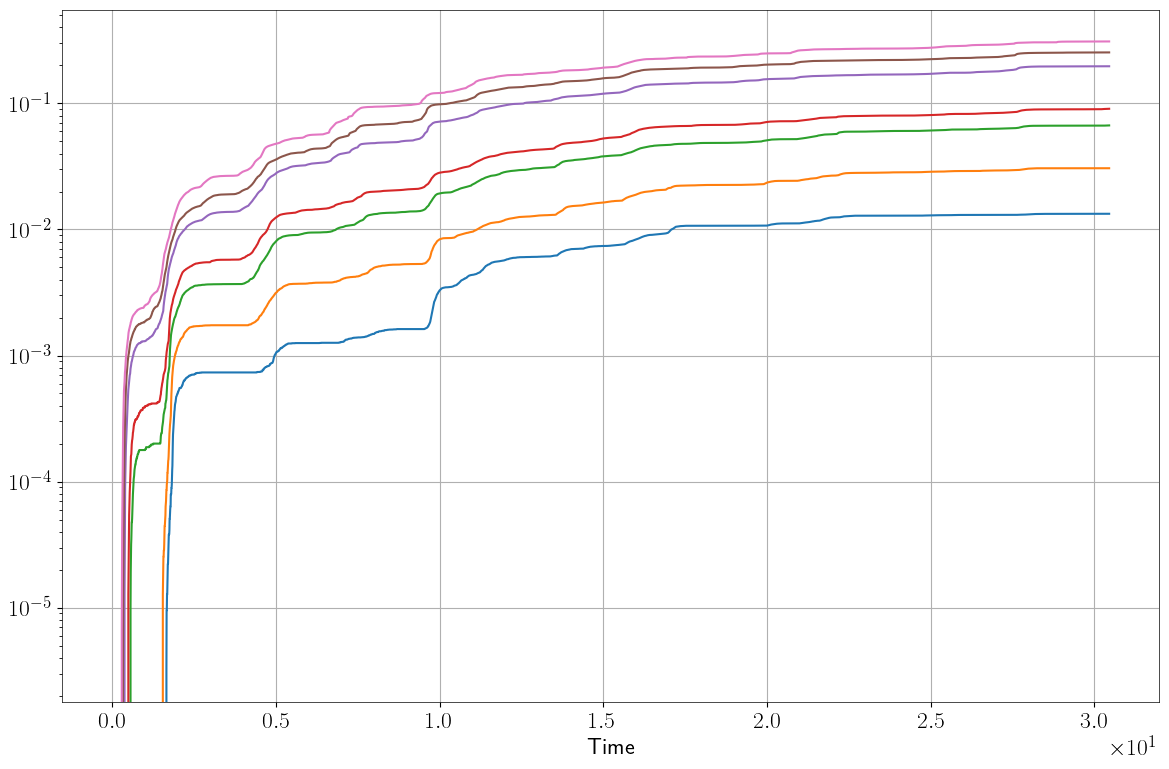

In [10]:
# %%
fig,ax = plt.subplots(1,1,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
st = 0.3
for alph in alpha_values[:]:
    with h5py.File(prtcl_loadPath(alph,st) / f"caus-details.hdf5",'r') as f:
            
        print(alph,f.keys(),end = '\n')
        ax.plot(times/(16.42),f['Caustics_ratio'][:],label=f'${alph}$')
    
ax.set_yscale("log")
ax.set_xlabel('Time')
ax.grid()

fig.tight_layout()



In [11]:
# %%
Qmax,Qmin = 1,-1
Qbins = np.linspace(Qmin,Qmax, 6001)
Qvals = 0.5*(Qbins[1:] + Qbins[:-1])
dQval  = Qvals[1] - Qvals[0]


In [12]:
# %%
st = 0.2
# tf = 4.0
# tp = st* tf
def Q_hists(st):
    Q_field_avg = np.zeros((alpha_values.size, Qvals.size))
    Q_particle_avg = np.zeros((alpha_values.size, Qvals.size))
    Q_caus_avg = np.zeros((alpha_values.size, Qvals.size))
    for ii,alph in enumerate(alpha_values[:]):
        with h5py.File(prtcl_loadPath(alph,st) / f"caus-details.hdf5",'r') as f:
                
            Q_field_avg[ii] = np.mean(f["Q_field_pdf"][:],axis = 0)
            Q_particle_avg[ii] = np.mean(f["Q_particle_pdf"][:],axis = 0)
            Q_caus_avg[ii] = np.mean(f["Q_caus_pdf"][:],axis = 0)
    
    return Q_field_avg,Q_particle_avg,Q_caus_avg
                


In [13]:
# %%
alph = 1.0
st = 0.4
with h5py.File(prtcl_loadPath(alph,st) / f"caus-details.hdf5",'r') as f:
    print(f['Q_caus_shifted'].shape)

(400, 644466)


In [14]:
# %%
# load_pgf_params()
savePlot

PosixPath('/home/rajarshi.chattopadhyay/pokemon_data/Plots/Re_125000.0,dt_0.005,N_1024')

np.float64(500.0)

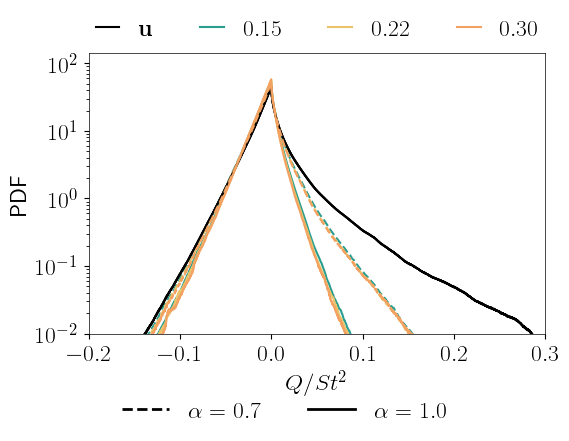

In [15]:
# %%
# load_pgf_params()
fig,ax = plt.subplots(1,1,figsize = (6,4.5))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
cls = custom_cmap(np.linspace(0,1,4))
ls = ['--','-']
# ax.plot(xdat,ydat,color ='black')
for ii, st in enumerate([0.2,0.3,0.4]):
    Q_field_avg,Q_particle_avg,Q_caus_avg = Q_hists(st)
    
    xdat = Qvals/(st*4.0)**2
    dxdat = xdat[1] - xdat[0]
    ydat = Q_field_avg[-1]/( dxdat )
    # print(st, dQval*(ydat*(np.abs(xdat)<0.2)).sum())
    if ii ==0 : ax.plot(xdat,ydat,label = fr"$\mathbf{{u}}$",color ='black',linewidth = 1.5)
    else: ax.plot(xdat,ydat,color ='black',linewidth = 1.5)

    ydat = Q_particle_avg[0]/dxdat  
    ax.plot(xdat,ydat, color = cls[ii],ls = ls[0],linewidth = 1.5)


    ydat = Q_particle_avg[-1]/dxdat  
    ax.plot(xdat,ydat,label = rf"${st*0.75:.2f}$",color = cls[ii],ls = ls[1],linewidth = 1.5)
ax.legend(handlelength = 1.0,ncols =4,bbox_to_anchor=(0.5, 1.2),loc = "upper center",frameon = False)
handles = [plt.Line2D([0], [0], lw=2,color="black", ls  =ls[0]),
           plt.Line2D([0], [0], lw=2, color="black",ls = ls[1])]    
leg = fig.legend(handles=handles, labels=[r'$\alpha = 0.7$',r'$\alpha = 1.0$'],handlelength = 2.,loc = "lower center",frameon = False,bbox_to_anchor=(0.5, -0.05),ncol=2)

# ydat = Q_caus_avg[0]/dQval  
# # ydat = Q_caus_shifted_pdf[0,-1]/(Qbins[1]- Qbins[0])
# ax.plot(Qvals,ydat,label = r"$\alpha = 0.7$",linestyle = "--")

# ydat = Q_caus_avg[-1]/dQval  
# # ydat = Q_caus_shifted_pdf[-1,-1]/(Qbins[1]- Qbins[0])
# ax.plot(Qvals,ydat,label = r"$\alpha = 1.0$",linestyle = "--")
# ydat = Q_caus_shifted_pdf[0,argminQ[0]]/(Qbins[1]- Qbins[0])
# ax.plot(Qvals,ydat,label = r"$\alpha = 0.7$",linestyle = "--")
# ydat = Q_caus_shifted_pdf[-1,argminQ[-1]]/(Qbins[1]- Qbins[0])
# ax.plot(Qvals,ydat,label = r"$\alpha = 1.0$",linestyle = "--")

# ydat = (minQ)[cond]*(3*xdat - 2)
ax.set_yscale('log')
ax.set_xlim(-0.2,0.3)
ax.set_xlabel(r'$Q/St^2$')
ax.set_ylabel(r'PDF')
# plt.plot(xdat,fit_array[0]*xdat+fit_array[1])
# ax.grid()
ax.set_ylim(1e-2,None)
plt.tight_layout()
# plt.save_pgf(fig,str(savePlot/f"Q_pdf_wo_caustics"),bbox_inches='tight', pad_inches=0.0)
# plt.savefig(savePlot/f"Q_pdf_wo_caustics.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"Q_pdf_wo_caustics.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')
# plt.savefig(savePlot/f"Q_pdf_wo_caustics.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
times[-1]


In [16]:
# %%
labels = ["(a)","(b)","(c)","(d)"]
bgcmap = ListedColormap([(0,0,0,0),(.96, .72, .97,0.6)])
# Qbins = np.linspace(-1.0,1.0,6001)
# Qvals = 0.5*(Qbins[1:]+Qbins[:-1])

# alpha_values = np.array([0.72,1.0])
cls = ["#219ebc", "#ffb703","#3a5a40"]
norm = TwoSlopeNorm(vmin=-3, vmax=0.0,vcenter = -1.5)
# Zbins  = np.linspace(-25,25,10001)
# Zvals = 0.5*(Zbins[1:]+Zbins[:-1])
# Z2bins = np.linspace(-625,625,1001)
# Z2vals = 0.5*(Z2bins[1:]+Z2bins[:-1])
# tbins = np.linspace(times[0],times[-1],20)
# tvals = 0.5*(tbins[1:]+tbins[:-1])
# Q_caus_shifted_pdf = np.zeros((len(alpha_values),len(times),len(Qvals)))
# Q_nc_shifted_pdf = np.zeros((len(alpha_values),len(times),len(Qvals)))
# TrZ_caus_shifted_pdf = np.zeros((len(alpha_values),len(times),len(Zvals)))
# TrZ_nc_shifted_pdf = np.zeros((len(alpha_values),len(times),len(Zvals)))
# TrZ2_caus_shifted_pdf = np.zeros((len(alpha_values),len(times),len(Z2vals)))
# TrZ2_nc_shifted_pdf = np.zeros((len(alpha_values),len(times),len(Z2vals)))
# t_caus_pdf = np.zeros((len(alpha_values),len(tvals)))
# Qmean1 = np.zeros((len(alpha_values),len(times)))
# Qmean2 = np.zeros((len(alpha_values),len(times)))
# Q_glob_min = -0.4629163643542112

# # %%
# Zbin_width = Zbins[1] - Zbins[0]
# Z2bin_width = Z2bins[1]-Z2bins[0]
# Qbin_width = Qbins[1]-Qbins[0]



In [17]:
# %%
def compute_extrema(x,y,count_number):
    """Outputs the value of x for which the derivative of y is zero 
    With a syntax copied from Microsoft Copilot.
    """
    tck = splrep(x,y,k = 5)
    tck_der = splder(tck)
    tck_2der = splder(tck,n=2)

    # print(PPoly.from_spline(tck_der).roots(extrapolate = False))
    try: 
        roots = PPoly.from_spline(tck_der).roots(extrapolate = False)
        der2_at_roots = splev(roots, tck_2der) 
        last_root = roots[der2_at_roots >0][-1] #! time for the last root 
    except :
        idx = -1 if y[-1] < y[0] else 0
        count_number += 1
        return x[idx],y[idx],count_number
    return x[x>last_root][0],y[x>last_root][0],count_number

def compute_next_minima(x,y,count_number):
    """Outputs the value of x for which the derivative of y is zero 
    With a syntax copied from Microsoft Copilot.
    """
    # print(PPoly.from_spline(tck_der).roots(extrapolate = False))
    if len(x) > 5:
        tck = splrep(x,y,k = 5)
        tck_der = splder(tck)
        tck_2der = splder(tck,n=2)
        try: 
            roots = PPoly.from_spline(tck_der).roots(extrapolate = False)
            der2_at_roots = splev(roots,tck_2der)
            first_root = roots[der2_at_roots>0][0] #! time for the last root where the 2nd derivative is less than zero. 
        except :
                idx = -1 if y[-1] < y[0] else 0
                count_number += 1
                return x[idx],y[idx],count_number
        return x[x<first_root][-1],y[x<first_root][-1],count_number
    else: 
        idx = -1 if y[-1] < y[0] else 0
        count_number += 1
        return x[idx],y[idx],count_number



In [18]:
# %%
# t1 = tt()
# st = 0.3
# Qmean1 = []
# Qmean2 = []
# caus_count = []
# for iiii,alph in enumerate(alpha_values):
    
#     print(f"Loading alpha = {alph} at {tt() - t1}",end="\r")
#     try: 
#         with h5py.File(prtcl_loadPath(alph,st = st) / f"caus-details.hdf5",'r') as f:
#             try: 
#                 Q_caus_shifted = f['Q_caus_shifted'][:]
#                 Q_nc_shifted = f['Q_nc_shifted'][:]
#                 TrZ_caus_shifted = f['TrZ_shifted'][:]
#                 TrZ_nc_shifted = f['TrZ_nc_shifted'][:]
#                 TrZ2_caus_shifted = f['TrZ2_shifted'][:]
#                 TrZ2_nc_shifted = f['TrZ2_nc_shifted'][:]
#                 t_caus_len = f['t_caus_len'][:]
#             except : 
#                 print(f.keys())
#                 continue
#             # dtimes = len(times)-len(Q_caus_shifted)
#             # print(f"dtimes is {dtimes}",end = "\r")
#     except FileNotFoundError: 
#         print(f"File not found for alpha = {alph}")
#         continue
#     time_loc = np.arange(0,Q_caus_shifted.shape[0]*0.1,0.1)
#     time_nc_loc = np.arange(0,Q_nc_shifted.shape[0]*0.1,0.1)
    
#     t_mins.append(np.zeros(Q_caus_shifted.shape[1]))
#     Q_mins.append(np.zeros(Q_caus_shifted.shape[1]))
#     count_number = 0
#     isnan = 0.
#     t_caus_len = np.zeros(Q_caus_shifted.shape[1])
#     for i in range(Q_caus_shifted.shape[1]):
#         cond = ~np.isnan(Q_caus_shifted[:,i])
#         regionlen = np.sum(cond)
#         t_caus_len[i] = regionlen
#         t_caus_local = times[:regionlen] - times[regionlen - 1]
#         t_mins[iiii][i],Q_mins[iiii][i],count_number = compute_extrema(t_caus_local,Q_caus_shifted[cond,i],count_number)
        

    
#     for i,time in enumerate(time_loc):  
#         isnan = np.isnan(Q_caus_shifted[i])
#         Q_caus_shifted_pdf[iiii,i] = np.histogram(Q_caus_shifted[i,~isnan],bins = Qbins,density = True)[0]
#         TrZ_caus_shifted_pdf[iiii,i] = np.histogram(TrZ_caus_shifted[i,~isnan],bins = Zbins,density = True)[0]
#         TrZ2_caus_shifted_pdf[iiii,i] = np.histogram(TrZ2_caus_shifted[i,~isnan],bins = Z2bins,density = True)[0]
#     for i,time in enumerate(time_nc_loc):        
#         isnan = np.isnan(Q_nc_shifted[i])
#         Q_nc_shifted_pdf[iiii,i] = np.histogram(Q_nc_shifted[i,~isnan],bins = Qbins,density = True)[0]
#         TrZ_nc_shifted_pdf[iiii,i] = np.histogram(TrZ_nc_shifted[i,~isnan],bins = Zbins,density = True)[0]
#         TrZ2_nc_shifted_pdf[iiii,i] = np.histogram(TrZ2_nc_shifted[i,~isnan],bins = Z2bins,density = True)[0]
        
        
#     t_caus_pdf[iiii] = np.histogram(t_caus_len,bins = tbins,density = True)[0]*(tbins[1]-tbins[0])
#     print(f"\nfor alpha = {alph} isnan = {isnan}\n Causcount = {Q_caus_shifted.shape}")    
#     caus_count.append(Q_caus_shifted.shape[1])
    
    
    
#     # t_caus_pdf[iiii] = t_caus_pdf[iiii]/np.where(np.sum(t_caus_pdf[iiii]) == 0, np.inf, np.sum(t_caus_pdf[iiii]))
    
#     Qmean1.append(np.sum(Qvals[None,:]*Q_caus_shifted_pdf[iiii],axis = 1)*(Qbins[1]-Qbins[0]))
#     Qmean2.append(np.nanmean(Q_caus_shifted ,axis = 1))
#     t1 = tt()
    
# Q_caus_shifted_pdf[:] = Q_caus_shifted_pdf*(Qbins[1]-Qbins[0])
# Q_nc_shifted_pdf[:] = Q_nc_shifted_pdf*(Qbins[1]-Qbins[0])
# TrZ_nc_shifted_pdf[:] = TrZ_nc_shifted_pdf*(Zbins[1]-Zbins[0])
# TrZ2_nc_shifted_pdf[:] = TrZ2_nc_shifted_pdf*(Z2bins[1]-Z2bins[0])
# TrZ_caus_shifted_pdf[:] = TrZ_caus_shifted_pdf*(Zbins[1]-Zbins[0])
# TrZ2_caus_shifted_pdf[:] = TrZ2_caus_shifted_pdf*(Z2bins[1]-Z2bins[0])


In [19]:
#%%

abins = np.linspace(-2.1,2.1,len(Qbins))
avals = 0.5*(abins[1:] + abins[:-1])
bbins = np.linspace(-2.1,2.1,len(Qbins))
bvals = 0.5*(bbins[1:] + bbins[:-1])
cbins = np.linspace(-2.1,2.1,len(Qbins))
cvals = 0.5*(cbins[1:] + cbins[:-1])
sig_shear_bins = np.linspace(0,2.1,len(Qbins))
sig_shear_vals = 0.5*(sig_shear_bins[1:] + sig_shear_bins[:-1])
sig_n_bins = np.linspace(0,2.1,len(Qbins))
sig_n_vals = 0.5*(sig_n_bins[1:] + sig_n_bins[:-1])
omg_bins = np.linspace(0,2.1,len(Qbins))
omg_vals = 0.5*(omg_bins[1:] + omg_bins[:-1])

#! sig_shear = b + c
#! sig_n = 2*a
#! omg = c - b

Zbins  = np.linspace(-25,25,10001)
Zvals = 0.5*(Zbins[1:]+Zbins[:-1])
Z2bins = np.linspace(-625,625,1001)
Z2vals = 0.5*(Z2bins[1:]+Z2bins[:-1])
tbins = np.linspace(times[0],times[-1],20)
tvals = 0.5*(tbins[1:]+tbins[:-1])
Q_caus_shifted_pdf = np.zeros((1,len(alpha_values),600,len(Qvals)))
Q_nc_shifted_pdf = np.zeros((1,len(alpha_values),1000,len(Qvals)))
a_caus_shifted_pdf = np.zeros((1,len(alpha_values),600,len(avals)))
a_nc_shifted_pdf = np.zeros((1,len(alpha_values),1000,len(avals)))
b_caus_shifted_pdf = np.zeros((1,len(alpha_values),600,len(bvals)))
b_nc_shifted_pdf = np.zeros((1,len(alpha_values),1000,len(bvals)))
c_caus_shifted_pdf = np.zeros((1,len(alpha_values),600,len(cvals)))
c_nc_shifted_pdf = np.zeros((1,len(alpha_values),1000,len(cvals)))
sig_shear_caus_shifted_pdf = np.zeros((1,len(alpha_values),600,len(cvals)))
sig_shear_nc_shifted_pdf = np.zeros((1,len(alpha_values),1000,len(cvals)))
sig_n_caus_shifted_pdf = np.zeros((1,len(alpha_values),600,len(cvals)))
sig_n_nc_shifted_pdf = np.zeros((1,len(alpha_values),1000,len(cvals)))
omg_caus_shifted_pdf = np.zeros((1,len(alpha_values),600,len(cvals)))
omg_nc_shifted_pdf = np.zeros((1,len(alpha_values),1000,len(cvals)))
TrZ_caus_shifted_pdf = np.zeros((1,len(alpha_values),600,len(Zvals)))
TrZ_nc_shifted_pdf = np.zeros((1,len(alpha_values),1000,len(Zvals)))
TrZ2_caus_shifted_pdf = np.zeros((1,len(alpha_values),600,len(Z2vals)))
TrZ2_nc_shifted_pdf = np.zeros((1,len(alpha_values),1000,len(Z2vals)))
t_caus_pdf = np.zeros((1,len(alpha_values),len(tvals)))
Qmean1 = np.zeros((1,len(alpha_values),len(times)))
Qmean2 = np.zeros((1,len(alpha_values),len(times)))
Q_glob_min = -0.4629163643542112

Zbin_width = Zbins[1] - Zbins[0]
Z2bin_width = Z2bins[1]-Z2bins[0]
Qbin_width = Qbins[1]-Qbins[0]

In [20]:
# %%

t1 = tt()
Qmean1 = []
Qmean2 = []
caus_count = []
t_mins = []
Q_mins = []
lentimes = []
lentimes_nc = []
for qq,st in enumerate([0.3,0.4]):
    # if qq==0: continue
    print(f"Loading st = {st}")
    for iiii,alph in enumerate(alpha_values):
    
        print(f"Loading alpha = {alph} at {tt() - t1}")
        try: 
            with h5py.File(prtcl_loadPath(alph,st = st) / f"caus-details.hdf5",'r') as f:
                try: 
                    Q_caus_shifted = f['Q_caus_shifted'][:]
                    Q_nc_shifted = f['Q_nc_shifted'][:]
                    a_caus_shifted = f['a_caus_shifted'][:]
                    a_nc_shifted = f['a_nc_shifted'][:]
                    b_caus_shifted = f['b_caus_shifted'][:]
                    b_nc_shifted = f['b_nc_shifted'][:]
                    c_caus_shifted = f['c_caus_shifted'][:]
                    c_nc_shifted = f['c_nc_shifted'][:]
                    TrZ_caus_shifted = f['TrZ_shifted'][:]
                    TrZ_nc_shifted = f['TrZ_nc_shifted'][:]
                    TrZ2_caus_shifted = f['TrZ2_shifted'][:]
                    TrZ2_nc_shifted = f['TrZ2_nc_shifted'][:]
                    t_caus_len = f['t_caus_len'][:]
                except : 
                    print(f"data loading failed for", st, alph,f.keys())
                    continue
                # dtimes = len(times)-len(Q_caus_shifted)
                # print(f"dtimes is {dtimes}",end = "\r")
        except FileNotFoundError: 
            print(f"File not found for alpha = {alph}")
            continue
        sig_shear_caus_shifted = np.abs(b_caus_shifted + c_caus_shifted)
        sig_n_caus_shifted = np.abs(2*a_caus_shifted)
        omg_caus_shifted = np.abs(c_caus_shifted - b_caus_shifted)
        sig_shear_nc_shifted = np.abs(b_nc_shifted + c_nc_shifted)
        sig_n_nc_shifted = np.abs(2*a_nc_shifted)
        omg_nc_shifted = np.abs(c_nc_shifted - b_nc_shifted)
        
        print(f"a range:{np.nanmin(a_caus_shifted)},{np.nanmin(a_nc_shifted)},{np.nanmax(a_caus_shifted)},{np.nanmax(a_nc_shifted)}")
        print(f"b range:{np.nanmin(b_caus_shifted)},{np.nanmin(b_nc_shifted)},{np.nanmax(b_caus_shifted)},{np.nanmax(b_nc_shifted)}")
        print(f"c range:{np.nanmin(c_caus_shifted)},{np.nanmin(c_nc_shifted)},{np.nanmax(c_caus_shifted)},{np.nanmax(c_nc_shifted)}")
        time_loc = np.arange(0,Q_caus_shifted.shape[0]*0.1,0.1)
        time_nc_loc = np.arange(0,Q_nc_shifted.shape[0]*0.1,0.1)
        lentimes.append(len(time_loc))
        lentimes_nc.append(len(time_nc_loc))
        print(Q_caus_shifted.shape)
        idx = len(alpha_values)*qq + iiii
        t_mins.append(np.zeros(Q_caus_shifted.shape[1]))
        
        Q_mins.append(np.zeros(Q_caus_shifted.shape[1]))
        count_number = 0
        isnan = 0.
        t_caus_len = np.zeros(Q_caus_shifted.shape[1])
        print(Q_mins[idx].shape,t_mins[idx].shape)
        for i in range(Q_caus_shifted.shape[1]):
            cond = ~np.isnan(Q_caus_shifted[:,i])
            regionlen = np.sum(cond)
            t_caus_len[i] = regionlen
            t_caus_local = time_loc[:regionlen] - time_loc[regionlen - 1]
            t_mins[idx][i],Q_mins[idx][i],count_number = compute_extrema(t_caus_local,Q_caus_shifted[cond,i],count_number)
            

        
        for i,time in enumerate(time_loc):  
            isnan = np.isnan(Q_caus_shifted[i])
            Q_caus_shifted_pdf[qq,iiii,i] = np.histogram(Q_caus_shifted[i,~isnan],bins = Qbins,density = True)[0]
            
            a_caus_shifted_pdf[qq,iiii,i] = np.histogram(a_caus_shifted[i,~isnan],bins = abins,density = True)[0]
            
            b_caus_shifted_pdf[qq,iiii,i] = np.histogram(b_caus_shifted[i,~isnan],bins = bbins,density = True)[0]
            
            c_caus_shifted_pdf[qq,iiii,i] = np.histogram(c_caus_shifted[i,~isnan],bins = cbins,density = True)[0]
            
            sig_shear_caus_shifted_pdf[qq,iiii,i] = np.histogram(sig_shear_caus_shifted[i,~isnan],bins = sig_shear_bins,density = True)[0]
            sig_n_caus_shifted_pdf[qq,iiii,i] = np.histogram(sig_n_caus_shifted[i,~isnan],bins = sig_n_bins,density = True)[0]
            omg_caus_shifted_pdf[qq,iiii,i] = np.histogram(omg_caus_shifted[i,~isnan],bins = omg_bins,density = True)[0]
            
            TrZ_caus_shifted_pdf[qq,iiii,i] = np.histogram(TrZ_caus_shifted[i,~isnan],bins = Zbins,density = True)[0]
            TrZ2_caus_shifted_pdf[qq,iiii,i] = np.histogram(TrZ2_caus_shifted[i,~isnan],bins = Z2bins,density = True)[0]
            
        for i,time in enumerate(time_nc_loc):        
            isnan = np.isnan(Q_nc_shifted[i])
            Q_nc_shifted_pdf[qq,iiii,i] = np.histogram(Q_nc_shifted[i,~isnan],bins = Qbins,density = True)[0]
            
            a_nc_shifted_pdf[qq,iiii,i] = np.histogram(a_nc_shifted[i,~isnan],bins = abins,density = True)[0]
            b_nc_shifted_pdf[qq,iiii,i] = np.histogram(b_nc_shifted[i,~isnan],bins = bbins,density = True)[0]
            c_nc_shifted_pdf[qq,iiii,i] = np.histogram(c_nc_shifted[i,~isnan],bins = cbins,density = True)[0]
            
            sig_shear_nc_shifted_pdf[qq,iiii,i] = np.histogram(sig_shear_nc_shifted[i,~isnan],bins = sig_shear_bins,density = True)[0]
            sig_n_nc_shifted_pdf[qq,iiii,i] = np.histogram(sig_n_nc_shifted[i,~isnan],bins = sig_n_bins,density = True)[0]
            omg_nc_shifted_pdf[qq,iiii,i] = np.histogram(omg_nc_shifted[i,~isnan],bins = omg_bins,density = True)[0]
            
            TrZ_nc_shifted_pdf[qq,iiii,i] = np.histogram(TrZ_nc_shifted[i,~isnan],bins = Zbins,density = True)[0]
            TrZ2_nc_shifted_pdf[qq,iiii,i] = np.histogram(TrZ2_nc_shifted[i,~isnan],bins = Z2bins,density = True)[0]
            
            
        t_caus_pdf[qq,iiii] = np.histogram(t_caus_len,bins = tbins,density = True)[0]*(tbins[1]-tbins[0])
        print(f"\nfor alpha = {alph} isnan = {isnan}\n Causcount = {Q_caus_shifted.shape}")    
        caus_count.append(Q_caus_shifted.shape[1])
    
    
    
    # t_caus_pdf[iiii] = t_caus_pdf[iiii]/np.where(np.sum(t_caus_pdf[iiii]) == 0, np.inf, np.sum(t_caus_pdf[iiii]))
    
        Qmean1.append(np.sum(Qvals[None,:]*Q_caus_shifted_pdf[qq,iiii],axis = 1)*(Qbins[1]-Qbins[0]))
        Qmean2.append(np.nanmean(Q_caus_shifted ,axis = 1))
        t1 = tt()




Loading st = 0.3
Loading alpha = 0.7 at 0.0013539791107177734


In [22]:
# %%
# caus_conts = [4155,9294,20232,26878,39221,59319,80710,104193]

In [23]:
#%% 
meant_min = []
meanQ_min = []
for i in range(len(t_mins)):
    meant_min.append(np.mean(t_mins[i]))
    meanQ_min.append(np.mean(Q_mins[i]))
    

In [33]:
# %%
for i,alpha in enumerate(alpha_values):
    print(f"Qmin for alpha = {alpha} {len(Q_mins[i])} particles have mean {np.mean(Q_mins[i])} and std {np.std(Q_mins[i])}")
    print(f"Qmin for alpha = {alpha} {len(Q_mins[i+len(alpha_values)])} particles have mean {np.mean(Q_mins[i+len(alpha_values)])} and std {np.std(Q_mins[i+len(alpha_values)])}")


Qmin for alpha = 0.7 4299 particles have mean -0.17891820901399588 and std 0.057608446154342706
Qmin for alpha = 0.7 48095 particles have mean -0.20847654465289228 and std 0.08444547519292765
Qmin for alpha = 0.72 10008 particles have mean -0.16120880422431588 and std 0.0546724646272031


IndexError: list index out of range

In [25]:
# %% 


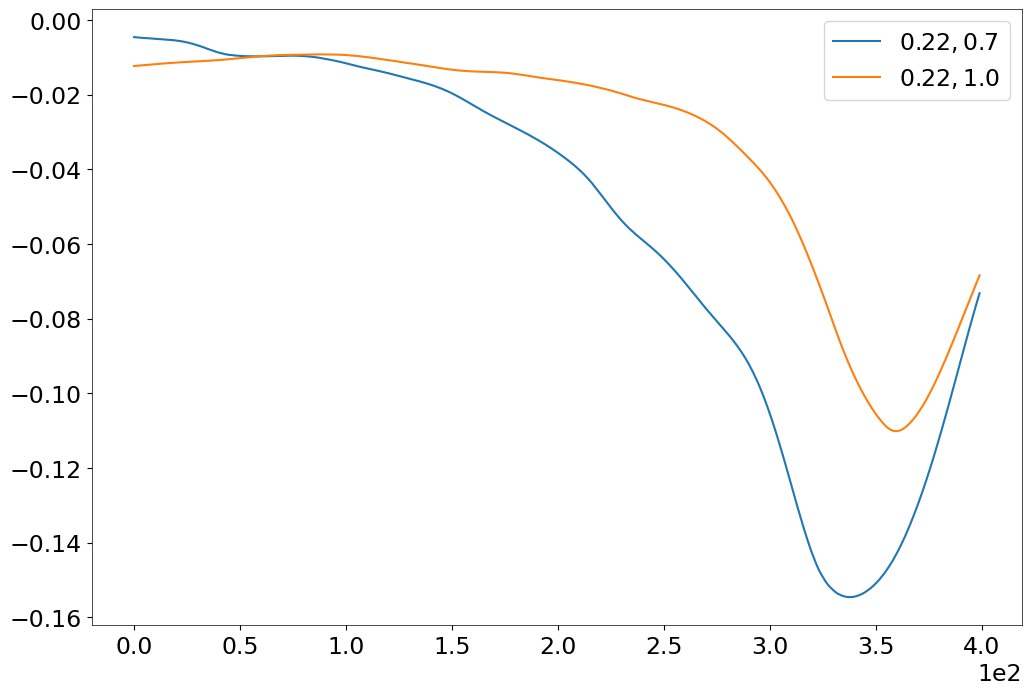

In [28]:
# %%
# for i,alpha in enumerate([0.7,1.0]):
plt.plot(Qmean2[0],label = f'${0.3*0.75:.2f}, {0.7}$')
# plt.plot(Qmean2[0 + len(alpha_values)],label = f'${0.4*0.75:.2f},{0.7}$')
plt.plot(Qmean2[len(alpha_values)-1],label = f'${0.3*0.75:.2f}, {1.0}$')
# plt.plot(Qmean2[-1 + 2*len(alpha_values)],label = f'${0.4*0.75:.2f},{1.0}$')
plt.legend()


In [29]:
# %%
len(Q_mins[0])

4299

In [32]:
minQ.shape

(7,)

IndexError: list index out of range

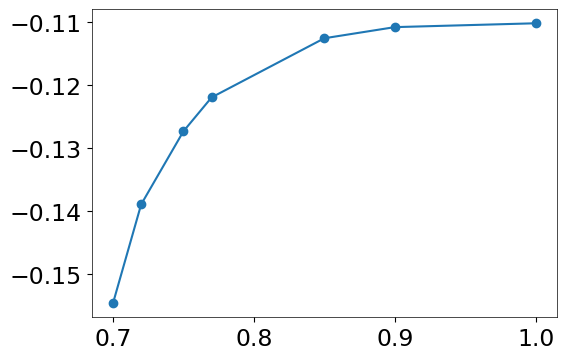

In [31]:
# %%
np.sum(t_caus_pdf,axis = 1)
# minQ = np.array([np.nanmean(Q_mins[alph]) for alph in range(0,len(alpha_values))])
minQ = np.nanmin(Qmean1[:alpha_values.size],axis = 1)
# minQ = np.nanmin(Qmean1[alpha_values.size:],axis = 1)
# mpl.rc("text", usetex = True)
# load_pgf_params()
fig,ax = plt.subplots(1,1,figsize = (6,4))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)

xdat = alpha_values
# xdat = (3*xdat-2)/(2-xdat)
ydat = (minQ)
# yfunc = -1/(xdat)**0.25
# yfunc = yfunc/yfunc[0]*ydat[0]

# err = np.linalg.norm(ydat-yfunc)/np.linalg.norm(ydat)
# print(err)
# fit = np.polyfit(xdat,ydat,1)
# y_fit = [  fit[0]*x + fit[1] for x in xdat]
# print(y_fit)
# y_expr = np.poly1d(fit)
# print(100*fit,y_expr)
ax.plot(xdat,ydat,'o-',label = f"St = {0.3*0.75:.2f}")

minQ = np.array([np.nanmean(Q_mins[len(alpha_values) + alph]) for alph in range(0,len(alpha_values))])
minQ = np.nanmin(Qmean1[alpha_values.size:],axis = 1)

xdat = alpha_values
xdat = (3*xdat-2)/(2-xdat)
ydat = (minQ)
ax.plot(xdat,ydat,'o-',label = f"St = {0.4*0.75:.2f}")
xq = np.linspace(0.7,1.0,50)
# xq = (3*xq-2)/(2-xq)
ax.plot(xq,-0.1*(1/(3*xq-2)),'--')
ax.text(0.75, 0.40, r'$-\left(\frac{1}{3\alpha -2}\right)$', fontsize=default_fontsize, ha='center', va='center', transform=ax.transAxes)
ax.plot(xq,-0.1*(xq/(3*xq-2)),'--')
ax.text(0.4, 0.30, r'$-\left(\frac{\alpha}{3\alpha -2}\right)$', fontsize=default_fontsize, ha='center', va='center', transform=ax.transAxes)
# ax.plot(xdat,yfunc,'x-')
ax.set_ylim(-0.17,-0.105)
ax.legend()
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\langle Q\rangle_{min}$')
# ax.set_ylim( -0.2,-0.1)
# plt.save_pgf(fig, str(savePlot/f"Q_min_scaling"), bbox_inches='tight', pad_inches=0.0)

# ax.grid()


 ### There is not much difference between the scaling of the mean of the min of each particle vs the min of the mean trajectory.

In [38]:
# %%
at = lambda alpha : (3*alpha-2)/(2-alpha)

In [39]:
#%%
times_nc = np.arange(a_nc_shifted_pdf.shape[-2])*0.1

# Qmean11[0].shape, tp

In [40]:
#%%
Q1_caus_shifted_pdf= Q_caus_shifted_pdf[...,:400,:]
a1_caus_shifted_pdf = a_caus_shifted_pdf[...,:400,:]
b1_caus_shifted_pdf = b_caus_shifted_pdf[...,:400,:]
c1_caus_shifted_pdf = c_caus_shifted_pdf[...,:400,:]
sig_shear1_caus_shifted_pdf = sig_shear_caus_shifted_pdf[...,:400,:]
sig_n1_caus_shifted_pdf = sig_n_caus_shifted_pdf[...,:400,:]
omg1_caus_shifted_pdf = omg_caus_shifted_pdf[...,:400,:]
TrZ1_caus_shifted_pdf = TrZ_caus_shifted_pdf[:,:,:400,:]
Qmean11 = []
for i in range(len(Qmean1)):
    Qmean11.append(Qmean1[i][:400])

In [41]:
#%%
Q1_nc_shifted_pdf = Q_nc_shifted_pdf[...,:800,:]
a1_nc_shifted_pdf = a_nc_shifted_pdf[...,:800,:]
b1_nc_shifted_pdf = b_nc_shifted_pdf[...,:800,:]
c1_nc_shifted_pdf = c_nc_shifted_pdf[...,:800,:]
sig_shear1_nc_shifted_pdf = sig_shear_nc_shifted_pdf[...,:800,:]
sig_n1_nc_shifted_pdf = sig_n_nc_shifted_pdf[...,:800,:]
omg1_nc_shifted_pdf = omg_nc_shifted_pdf[...,:800,:]


TrZ1_nc_shifted_pdf = TrZ_nc_shifted_pdf[:,:,:800,:]

In [42]:
#%%


times_nc = np.arange(a1_nc_shifted_pdf.shape[-2])*0.1
times_caus = np.arange(a1_caus_shifted_pdf.shape[-2])*0.1


In [ ]:
#%%
def save_dset(f,dname,data):
    if dname in f:
        del f[dname]
    
    f.create_dataset(dname, data = data, dtype = np.float64, compression = 'gzip')
    return f[dname]



In [ ]:
#%%
#? Saving to hdf5 files 
stokes = [0.225]
with h5py.File(f"plot_data.hdf5", "a") as f:
    for i in range(len(stokes)):
        try: group = f.create_group(f"st_{stokes[i]:.2f}") 
        except ValueError: 
            del f[f"st_{stokes[i]:.2f}"]
            group = f.create_group(f"st_{stokes[i]:.2f}") 
        save_dset(group,"Qvals",Qvals)
        save_dset(group,"avals",avals)
        save_dset(group,"bbins",bvals)
        save_dset(group,"cbins",cvals)
        save_dset(group,"sig_shear_vals",sig_shear_vals)
        save_dset(group,"sig_n_vals",sig_n_vals)
        save_dset(group,"omg_vals",omg_vals)
        save_dset(group,"trz_vals",Zvals)
        
        
        save_dset(group,"meanQ_min",meanQ_min)
        save_dset(group,"meant_min",meant_min)
        save_dset(group,"times_c",times_caus)
        save_dset(group,"Q_caus_shifted_pdf",Q1_caus_shifted_pdf[i])
        save_dset(group,"a_caus_shifted_pdf",a1_caus_shifted_pdf[i])
        save_dset(group,"b_caus_shifted_pdf",b1_caus_shifted_pdf[i])
        save_dset(group,"c_caus_shifted_pdf",c1_caus_shifted_pdf[i])
        save_dset(group,"sig_shear_caus_shifted_pdf",sig_shear1_caus_shifted_pdf[i])   
        save_dset(group,"sig_n_caus_shifted_pdf",sig_n1_caus_shifted_pdf[i])
        save_dset(group,"omg_caus_shifted_pdf",omg1_caus_shifted_pdf[i])
        save_dset(group,"Qmean1",Qmean11[len(alpha_values)*i :len(alpha_values)*(i+1)] )    
        save_dset(group,"TrZ_caus_shifted_pdf",TrZ1_caus_shifted_pdf[i])
        # save_dset(group,"t_caus_pdf",t_caus_pdf[i])
        # save_dset(group,"t_mins",t_mins[i])
        # save_dset(group,"Q_mins",Q_mins[i])
        
        
        save_dset(group,"times_nc",times_nc)
        save_dset(group,"Q_nc_shifted_pdf",Q1_nc_shifted_pdf[i])
        save_dset(group,"a_nc_shifted_pdf",a1_nc_shifted_pdf[i])
        save_dset(group,"b_nc_shifted_pdf",b1_nc_shifted_pdf[i])
        save_dset(group,"c_nc_shifted_pdf",c1_nc_shifted_pdf[i])
        save_dset(group,"sig_shear_nc_shifted_pdf",sig_shear1_nc_shifted_pdf[i])
        save_dset(group,"sig_n_nc_shifted_pdf",sig_n1_nc_shifted_pdf[i])
        save_dset(group,"omg_nc_shifted_pdf",omg1_nc_shifted_pdf[i])
        save_dset(group,"TrZ_nc_shifted_pdf",TrZ1_nc_shifted_pdf[i])
        




## Making Fig. 4

In [193]:
dZval = Zvals[1] - Zvals[0]
st

0.225

/tmp/ipykernel_449800/662884629.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad = 0.1,h_pad = 1.0)


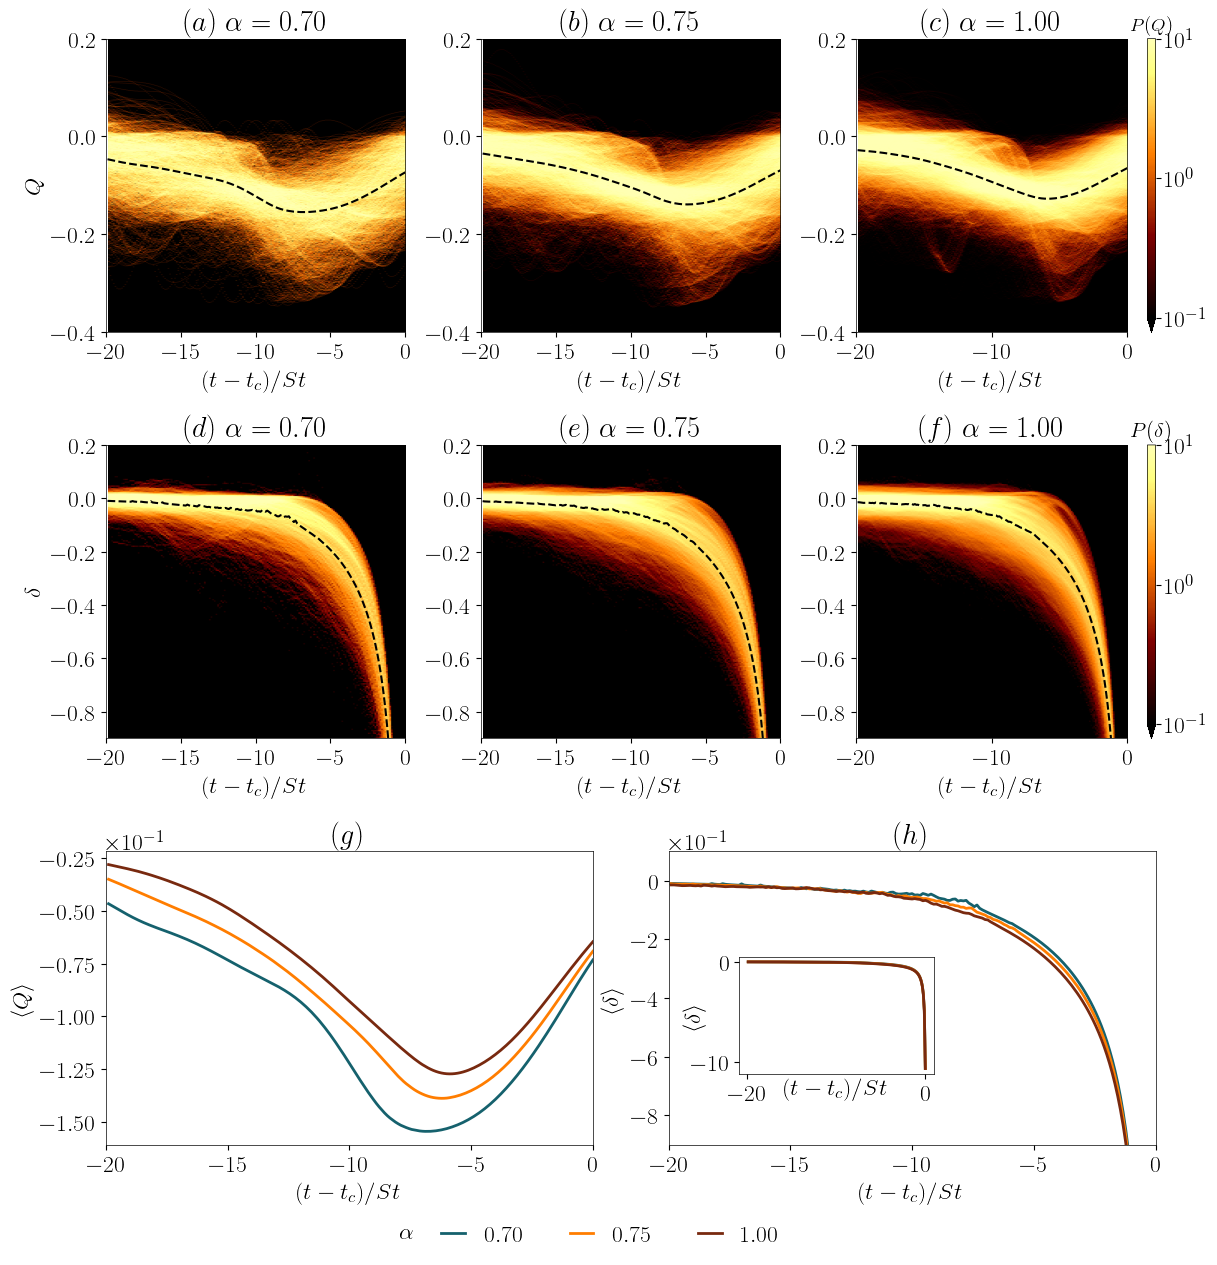

In [201]:
# %%
st = 0.225
times_loc = np.arange(0,40,0.1)
times_rescaled = (times_loc - times_loc[-1])/(st*4.0)
cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
cmap = plt.cm.afmhot
cmap= plt.cm.colors.LinearSegmentedColormap.from_list("cmap90", cmap(np.linspace(0, 0.85, 256)))
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1

mpl.rcParams['text.usetex'] = True

nums = ["(a)","(b)","(c)","(d)","(e)","(f)","(g)","(h)"]
cls = ["15616d","ff7d00","78290f"]
fig = plt.figure(figsize = (12,12))
gs = mpl.gridspec.GridSpec(3, 6, figure=fig)
ax11 = fig.add_subplot(gs[0, 0:2] )
ax12 = fig.add_subplot(gs[0, 2:4] )
ax13 = fig.add_subplot(gs[0, 4:6] )
ax21 = fig.add_subplot(gs[1, 0:2] )
ax22 = fig.add_subplot(gs[1, 2:4] )
ax23 = fig.add_subplot(gs[1, 4:6] )
ax31 = fig.add_subplot(gs[2, :3] )
ax32 = fig.add_subplot(gs[2, 3:6] )
inset_ax = inset_axes(ax32, width="40%", height="40%", loc="lower left",borderpad = 3) 
axs = [ax11, ax12, ax13,ax21,ax22,ax23, ax31,ax32]
labels = []
handles = []
for ax in axs:
    ax.set_xlabel(r'$(t-t_c)/St$')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    ax.set_xlim(-20,0)

ax11.set_ylabel(r'$Q$')
ax21.set_ylabel(r'$\delta$')
Q_caus_pdf_mean = np.zeros((len(alphs),Qmean11[0].shape[-1]))
for i,alph in enumerate(alphs):
    xdat = times_rescaled[cond]
    
    
    ydat = np.log10(np.clip(Q1_caus_shifted_pdf[stidx,i,cond].T,1e-10,None))
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    imQ = axs[i].imshow(
    ydat,
    cmap=cmap,
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], Qvals[0], Qvals[-1]],
    aspect='auto'
)
    
    ydat = np.log10(np.clip(TrZ1_caus_shifted_pdf[stidx,i,cond].T,1e-10,None))
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    imZ = axs[i+ len(alphs)].imshow(
    ydat,
    cmap=cmap,
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], Zvals[0], Zvals[-1]],
    aspect='auto'
)   
    Qmean = np.sum(Qvals[None,:]*Q1_caus_shifted_pdf[stidx,i,cond],axis = 1)*dQval
    TrZmean = np.sum(Zvals[None,:]*TrZ1_caus_shifted_pdf[stidx,i,cond],axis = 1)*dZval

    axs[i].plot(xdat,Qmean, 'black',ls = '--')
    axs[i + len(alphs)].plot(xdat,TrZmean, 'black',ls = '--')


    h1, = ax31.plot(xdat,Qmean,color ="#" + cls[i],label = fr"$ {alph:.2f}$",lw= 2)
    ax32.plot(xdat,TrZmean,color ="#" + cls[i],label = fr"$ {alph:.2f}$",lw= 2)
    inset_ax.plot(xdat,TrZmean,color ="#" + cls[i],label = fr"$ {alph:.2f}$",lw= 2)
    axs[i].set_title(fr"${nums[i]}~ \alpha = {alph:.2f}$")
    axs[i + len(alphs)].set_title(fr"${nums[i+ len(alphs)]}~ \alpha = {alph:.2f}$")


    axs[i].set_ylim(-0.4,0.2)
    axs[i+len(alphs)].set_ylim(-0.9,0.2)
    
    handles.append(h1)
    labels.append(fr"${alph:.2f}$")


ax31.ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax32.ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
inset_ax.ticklabel_format(style = "sci",axis = "both",scilimits = (-2,2))
inset_ax.set_xlabel(r'$(t-t_c)/St$',labelpad = -20)
inset_ax.set_ylabel(r'$\langle \delta \rangle$',labelpad = -12)
ax31.set_ylabel(r'$\langle Q \rangle$')
ax32.set_ylabel(r'$\langle \delta \rangle$')
ax32.set_ylim(-0.9,0.1)

ax31.set_title(r'$(g)$')
ax32.set_title(r'$(h)$')

divider = make_axes_locatable(ax13)
caxQ = divider.append_axes("right", size="3%", pad=0.2)
cbarQ = fig.colorbar(imQ,cax = caxQ,orientation="vertical", shrink=0.5,extend = 'min')
cbarQ.ax.set_title(r"$P(Q)$",rotation = 0,fontsize = 0.8*default_fontsize)
cbarQ.set_ticks([-1,0,1])
cbarQ.ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter( lambda val, pos: r"$10^{%d}$" % val))

divider =make_axes_locatable(ax23)
caxZ = divider.append_axes("right",size = "3%",pad = 0.2)
cbarZ = fig.colorbar(imZ,cax = caxZ,orientation="vertical", shrink=0.5,extend = 'min')
cbarZ.ax.set_title(r"$P(\delta)$",rotation = 0,fontsize = 0.9*default_fontsize)
cbarZ.ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter( lambda val, pos: r"$10^{%d}$" % val))
cbarZ.set_ticks([-1,0,1])


leg =fig.legend(handles,labels, loc = 'lower center',bbox_to_anchor = (0.5,-0.05),handlelength = 1,ncols = 3,frameon =False)
fig.text(0.33,-0.03, r"$\alpha$",ha = "center",va = 'bottom')

fig.tight_layout(pad = 0.1,h_pad = 1.0)
fig.savefig(f"/home/rajarshi.chattopadhyay/pokemon_data/Plots/bspline/Re_125000.0,dt_0.005,N_1024/q_trz_pdf_mean_st_{st:.3f}.pdf",bbox_inches = "tight",dpi = 300,format = "pdf")
fig.savefig(f"/home/rajarshi.chattopadhyay/pokemon_data/Plots/bspline/Re_125000.0,dt_0.005,N_1024/q_trz_pdf_mean_st_{st:.3f}.png",bbox_inches = "tight",dpi = 300,format = "png")

## Making Fig. 6

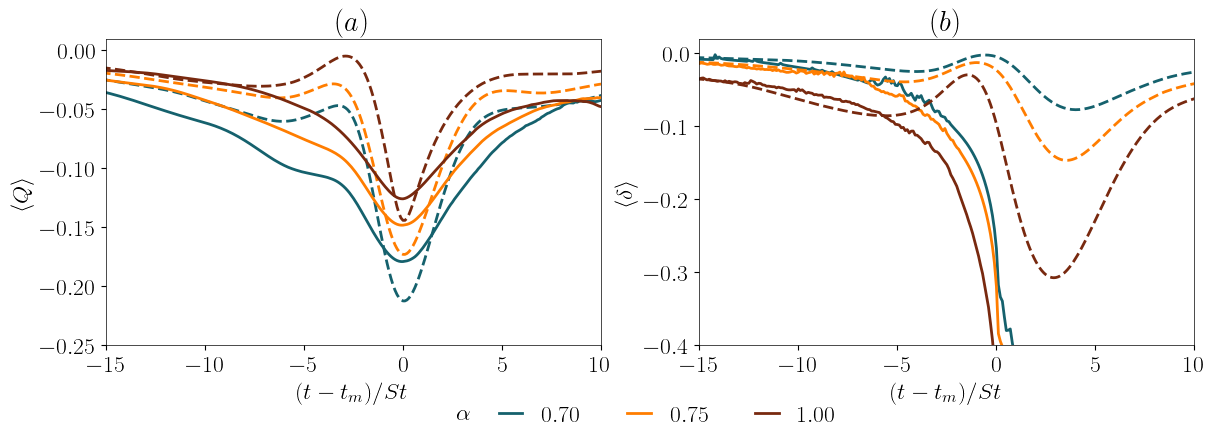

In [240]:
alphs = [0.7,0.75, 1.0] 
mpl.rcParams['text.usetex'] = True
nums = ["(a)","(b)","(c)","(d)","(e)","(f)","(g)","(h)"]
cls = ["15616d","ff7d00","78290f"]
fig = plt.figure(figsize = (12,4))
gs = mpl.gridspec.GridSpec(1, 2, figure=fig)
ax1 = fig.add_subplot(gs[0] )
ax2 = fig.add_subplot(gs[1] )
axs = [ax1,ax2]
labels = []
handles = []
for ax in axs:
    ax.set_xlabel(r'$(t-t_m)/St$')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    ax.set_xlim(-15,10)
ax1.set_ylabel(r'$\langle Q \rangle$')
ax2.set_ylabel(r'$\langle \delta \rangle$')
ax1.set_ylim(-0.25,0.01)
ax2.set_ylim(-0.4,0.02)
ax1.set_title(r'$(a)$')
ax2.set_title(r'$(b)$')
for i,alph in enumerate(alphs): 
    with h5py.File("/home/rajarshi.chattopadhyay/pokemon_data/Plots/bspline/tm_shifted_mean_data.hdf5") as f:
        grp = f[f"Re_{Re}_dt_{dt}_N_{N}/alpha_{alph:.2f}_st_{0.75}/"]
        t = grp["t"][:]
        Q_caus = grp["Q_caus_mean"][:]
        Q_nc = grp["Q_nc_mean"][:]
        TrZ_caus = grp["TrZ_caus_mean"][:]
        TrZ_nc = grp["TrZ_nc_mean"][:]
    h1, = ax1.plot(t,Q_caus, color = "#" + cls[i],lw = 2)
    ax1.plot(t,Q_nc, color = "#" + cls[i],lw = 2,ls = '--')
    ax2.plot(t,TrZ_caus, color = "#" + cls[i],lw = 2,ls = '-')
    ax2.plot(t,TrZ_nc, color = "#" + cls[i],lw = 2,ls = '--')
    handles.append(h1)
    labels.append(fr"${alph:.2f}$")
    
leg = fig.legend(handles, labels, loc = 'lower center',bbox_to_anchor = (0.55,-0.1),handlelength = 1, ncols = 3,frameon = False)
fig.text(0.38,-0.043, r"$\alpha$",ha = "center",va = 'bottom')
fig.tight_layout(pad = 0.1,h_pad = 1.0)
fig.savefig(f"/home/rajarshi.chattopadhyay/pokemon_data/Plots/bspline/Re_125000.0,dt_0.005,N_1024/q_trz_c_nc_st_{st:.3f}.png",bbox_inches = "tight",dpi = 300,format = "png")
fig.savefig(f"/home/rajarshi.chattopadhyay/pokemon_data/Plots/bspline/Re_125000.0,dt_0.005,N_1024/q_trz_c_nc_st_{st:.3f}.pdf",bbox_inches = "tight",dpi = 300,format = "pdf")

/tmp/ipykernel_449800/1703096828.py:27: RuntimeWarning: divide by zero encountered in log10
  ydat = np.log10(Q1_caus_shifted_pdf[stidx,i,cond].T)


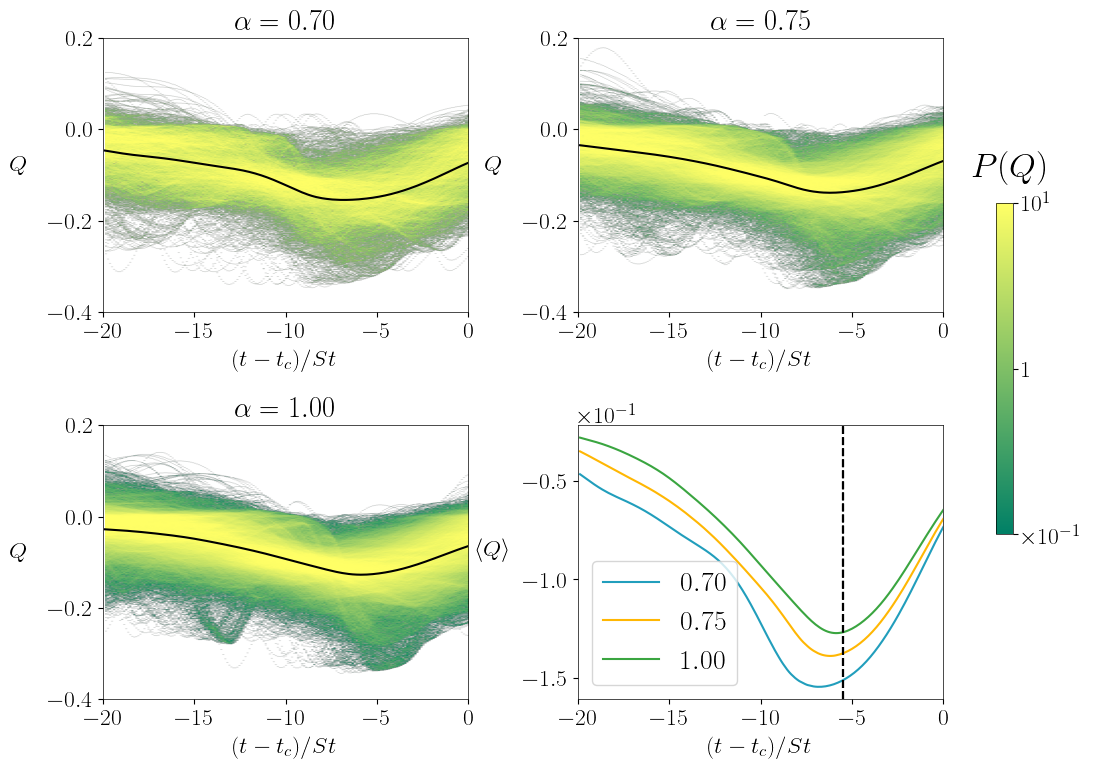

In [43]:
# %%
st = 0.225
times_loc = np.arange(0,40,0.1)
times_rescaled = (times_loc - times_loc[-1])/(st*4.0)
cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 

# load_pgf_params()
mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
Q_caus_pdf_mean = np.zeros((len(alphs),Qmean11[0].shape[-1]))
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled[cond]
    ydat = np.log10(Q1_caus_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], Qvals[0], Qvals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    ydat = Qmean11[i + offset][cond]
    Q_caus_pdf_mean[i] = Qmean11[i+ offset]
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$Q$',rotation = 0,labelpad =20)
    # ax[ind1,ind2].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')
    

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(-0.4,0.2)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_c)/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,0)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle Q \rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(Q)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.save_pgf(fig,str(savePlot/f"q_caus_hist_st_{st:.2f}"))
# plt.savefig(savePlot/f"q_caus_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"q_caus_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"q_caus_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')


In [ ]:
# %%

Q_nc_shifted_pdf.shape

/tmp/ipykernel_449800/3420584016.py:27: RuntimeWarning: divide by zero encountered in log10
  ydat = np.log10(Q1_nc_shifted_pdf[stidx,i,cond].T)


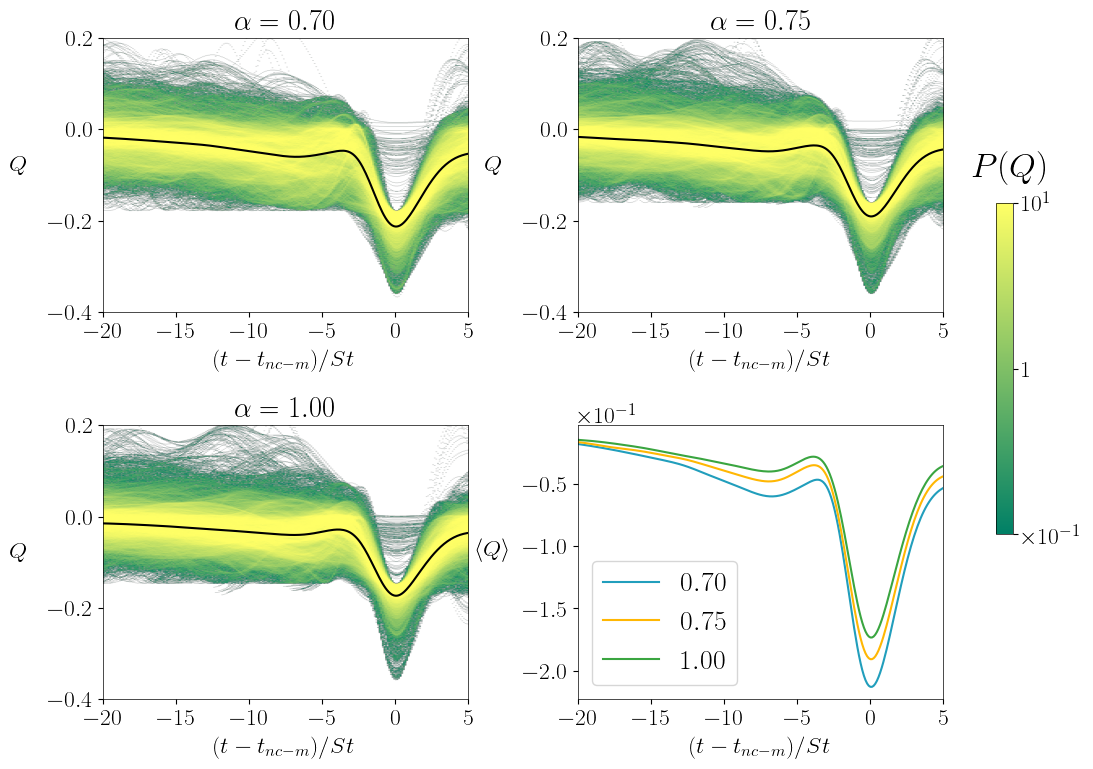

In [202]:
#%% 
st = 0.225
times_loc = np.arange(-20,20,0.1)
times_rescaled = (times_loc)/(st*4.0)
# cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 
cond = slice(len(times_nc)//2- len(times_loc)//2,len(times_nc)//2+len(times_loc)//2)
mpl.rc("text", usetex = False)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
Q_nc_pdf_mean = np.zeros((len(alphs),Q1_nc_shifted_pdf.shape[2]))

if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled 
    ydat = np.log10(Q1_nc_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], Qvals[0], Qvals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)

    Q_nc_pdf_mean[i] = np.sum(Qvals[None,:]*Q1_nc_shifted_pdf[stidx,i],axis = 1)*dQval
    ydat = Q_nc_pdf_mean[i][cond]
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$Q$',rotation = 0,labelpad =20)
    ax[ind1,ind2].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(-0.4,0.2)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_{nc-m})/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,5)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle Q \rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(Q)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.savefig(savePlot/f"q_nc_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"q_nc_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"q_nc_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')






NameError: name 'a1_caus_shifted_pdf' is not defined

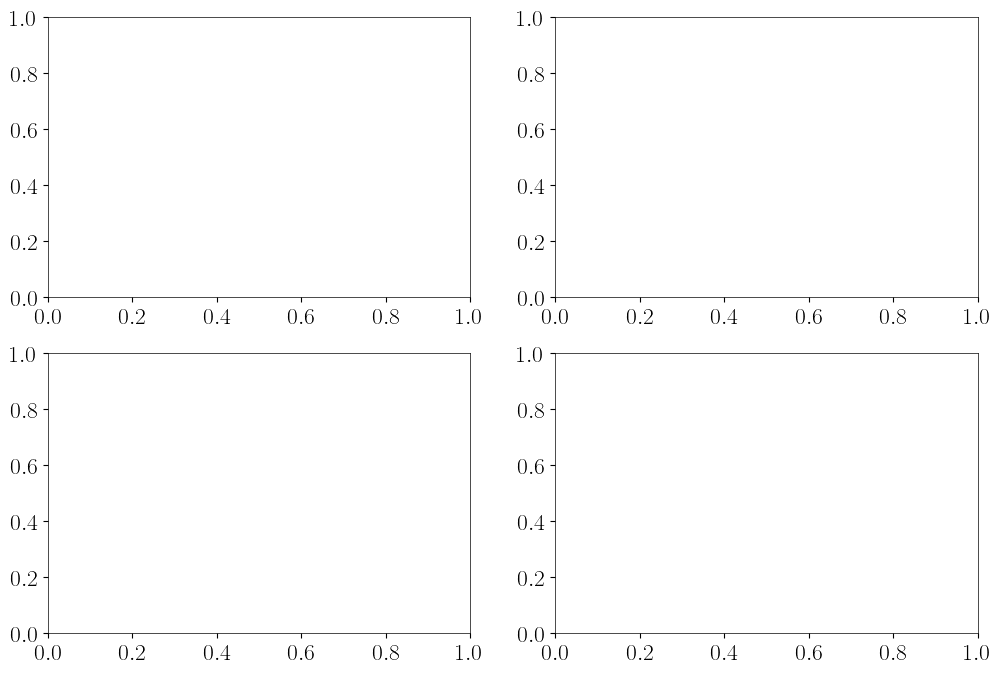

In [34]:
#%%

st = 0.225
times_loc = np.arange(0,40,0.1)
times_rescaled = (times_loc - times_loc[-1])/(st*4.0)
cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 

# load_pgf_params()
mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled[cond]
    ydat = np.log10(a1_caus_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], avals[0], avals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    daval = avals[1] - avals[0]
    ydat = np.sum(avals[None,:]*a1_caus_shifted_pdf[stidx,i,cond],axis = 1)*daval
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$a$',rotation = 0,labelpad =20)
    # ax[ind1,ind2].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')
    

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(-1,1)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_c)/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,0)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle a \rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(a)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.save_pgf(fig,str(savePlot/f"q_caus_hist_st_{st:.2f}"))
# plt.savefig(savePlot/f"a_caus_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"a_caus_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"a_caus_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')


In [ ]:
#%%

In [ ]:
#%%
st = 0.225
times_loc = np.arange(-20,20,0.1)
times_rescaled = (times_loc)/(st*4.0)
# cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 
cond = slice(len(times_nc)//2- len(times_loc)//2,len(times_nc)//2+len(times_loc)//2)

mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled 
    ydat = np.log10(a1_nc_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], avals[0], avals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    daval = avals[1] - avals[0]
    amean11= np.sum(avals[None,:]*a1_nc_shifted_pdf[stidx,i],axis = 1)*daval
    ydat = amean11[cond]
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$a$',rotation = 0,labelpad =20)
    ax[ind1,ind2].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(-1,1)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_{nc-m})/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,5)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle a \rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(a)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.savefig(savePlot/f"a_nc_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"a_nc_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"a_nc_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')


In [ ]:
#%%

st = 0.225
times_loc = np.arange(0,40,0.1)
times_rescaled = (times_loc - times_loc[-1])/(st*4.0)
cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 

# load_pgf_params()
mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled[cond]
    ydat = np.log10(b1_caus_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], bvals[0], bvals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    dbval = bvals[1] - bvals[0]
    ydat = np.sum(bvals[None,:]*b1_caus_shifted_pdf[stidx,i,cond],axis = 1)*dbval
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$b$',rotation = 0,labelpad =20)
    # ax[ind1,ind2].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')
    

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(-1,1)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_c)/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,0)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle b \rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(b)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.save_pgf(fig,str(savePlot/f"q_caus_hist_st_{st:.2f}"))
# plt.savefig(savePlot/f"b_caus_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"b_caus_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"b_caus_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')


In [ ]:
#%%

In [ ]:
#%%
st = 0.225
times_loc = np.arange(-20,20,0.1)
times_rescaled = (times_loc)/(st*4.0)
# cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 
cond = slice(len(times_nc)//2- len(times_loc)//2,len(times_nc)//2+len(times_loc)//2)

mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled 
    ydat = np.log10(b1_nc_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], bvals[0], bvals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    dbval = bvals[1] - bvals[0]
    bmean11= np.sum(bvals[None,:]*b1_nc_shifted_pdf[stidx,i],axis = 1)*dbval
    ydat = bmean11[cond]
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$b$',rotation = 0,labelpad =20)
    ax[ind1,ind2].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(-1,1)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_{nc-m})/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,5)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle b \rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(b)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.savefig(savePlot/f"b_nc_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"b_nc_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"b_nc_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')


In [ ]:
#%%
st = 0.225
times_loc = np.arange(0,40,0.1)
times_rescaled = (times_loc - times_loc[-1])/(st*4.0)
cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 

# load_pgf_params()
mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled[cond]
    ydat = np.log10(c1_caus_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], cvals[0], cvals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    dcval = cvals[1] - cvals[0]
    ydat = np.sum(cvals[None,:]*c1_caus_shifted_pdf[stidx,i,cond],axis = 1)*dcval
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$c$',rotation = 0,labelpad =20)
    # ax[ind1,ind2].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')
    

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(-1,1)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_c)/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,0)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle c \rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(c)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.save_pgf(fig,str(savePlot/f"q_caus_hist_st_{st:.2f}"))
# plt.savefig(savePlot/f"c_caus_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"c_caus_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"c_caus_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')


In [ ]:
#%%

In [ ]:
#%%
st = 0.225
times_loc = np.arange(-20,20,0.1)
times_rescaled = (times_loc)/(st*4.0)
# cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 
cond = slice(len(times_nc)//2- len(times_loc)//2,len(times_nc)//2+len(times_loc)//2)

mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled 
    ydat = np.log10(c1_nc_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], cvals[0], cvals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    dcval = cvals[1] - cvals[0]
    cmean11= np.sum(cvals[None,:]*c1_nc_shifted_pdf[stidx,i],axis = 1)*dcval
    ydat = cmean11[cond]
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$c$',rotation = 0,labelpad =20)
    ax[ind1,ind2].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(-1,1)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_{nc-m})/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,5)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle c \rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(c)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.savefig(savePlot/f"c_nc_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"c_nc_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"c_nc_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')


In [ ]:
#%%
st = 0.225
times_loc = np.arange(0,40,0.1)
times_rescaled = (times_loc - times_loc[-1])/(st*4.0)
cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 

# load_pgf_params()
mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
sig_shear_caus_pdf_mean = np.zeros((len(alphs),sig_shear1_caus_shifted_pdf.shape[2]))

if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled[cond]
    ydat = np.log10(sig_shear1_caus_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], sig_shear_vals[0], sig_shear_vals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    dsig_shearval = sig_shear_vals[1] - sig_shear_vals[0]
    sig_shear_caus_pdf_mean[i] = np.sum(sig_shear_vals[None,:]*sig_shear1_caus_shifted_pdf[stidx,i],axis = 1)*dsig_shearval
    ydat = np.sum(sig_shear_vals[None,:]*sig_shear1_caus_shifted_pdf[stidx,i,cond],axis = 1)*dsig_shearval
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$|\sigma_s|$',rotation = 0,labelpad =20)
    # ax[ind1,ind2].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')
    

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(0,None)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_c)/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,0)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle |\sigma_s| \rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(|\sigma_s|)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.save_pgf(fig,str(savePlot/f"sig_shear_caus_hist_st_{st:.2f}"))
# plt.savefig(savePlot/f"sig_shear_caus_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"sig_shear_caus_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"sig_shear_caus_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')


In [ ]:
#%%

In [ ]:
#%%
st = 0.225
times_loc = np.arange(-20,20,0.1)
times_rescaled = (times_loc)/(st*4.0)
# cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 
cond = slice(len(times_nc)//2- len(times_loc)//2,len(times_nc)//2+len(times_loc)//2)

mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
sig_shear_nc_pdf_mean = np.zeros((len(alphs),sig_shear1_nc_shifted_pdf.shape[2]))
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled 
    ydat = np.log10(sig_shear1_nc_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], sig_shear_vals[0], sig_shear_vals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    dsig_shear_val = sig_shear_vals[1] - sig_shear_vals[0]
    sig_shear_nc_pdf_mean[i] = np.sum(sig_shear_vals[None,:]*sig_shear1_nc_shifted_pdf[stidx,i],axis = 1)*dsig_shearval
    sig_shear_mean11= np.sum(sig_shear_vals[None,:]*sig_shear_nc_shifted_pdf[stidx,i],axis = 1)*dsig_shear_val
    ydat = sig_shear_mean11[cond]
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$|\sigma_s|$',rotation = 0,labelpad =20)
    ax[ind1,ind2].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(0,None)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_{nc-m})/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,5)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle| \sigma_s |\rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(|\sigma_s|)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.savefig(savePlot/f"sig_shear_nc_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"sig_shear_nc_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"sig_shear_nc_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')

In [ ]:
#%%

st = 0.225
times_loc = np.arange(0,40,0.1)
times_rescaled = (times_loc - times_loc[-1])/(st*4.0)
cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 

# load_pgf_params()
mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
sig_n_caus_pdf_mean = np.zeros((len(alphs),sig_n1_caus_shifted_pdf.shape[2]))
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled[cond]
    ydat = np.log10(sig_n1_caus_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], sig_n_vals[0], sig_n_vals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    dsig_nval = sig_n_vals[1] - sig_n_vals[0]
    sig_n_caus_pdf_mean[i] = np.sum(sig_n_vals[None,:]*sig_n1_caus_shifted_pdf[stidx,i],axis = 1)*dsig_nval
    ydat = np.sum(sig_n_vals[None,:]*sig_n1_caus_shifted_pdf[stidx,i,cond],axis = 1)*dsig_nval
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$|\sigma_n|$',rotation = 0,labelpad =20)
    # ax[ind1,ind2].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')
    

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(0,None)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_c)/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,0)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle |\sigma_n |\rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(|\sigma_n|)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.save_pgf(fig,str(savePlot/f"q_caus_hist_st_{st:.2f}"))
# plt.savefig(savePlot/f"sig_n_caus_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"sig_n_caus_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"sig_n_caus_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')


In [ ]:
#%%

In [ ]:
#%%
st = 0.225
times_loc = np.arange(-20,20,0.1)
times_rescaled = (times_loc)/(st*4.0)
# cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 
cond = slice(len(times_nc)//2- len(times_loc)//2,len(times_nc)//2+len(times_loc)//2)

mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
sig_n_nc_pdf_mean = np.zeros((len(alphs),sig_n1_nc_shifted_pdf.shape[2]))
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled 
    ydat = np.log10(sig_n1_nc_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], sig_n_vals[0], sig_n_vals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    dsig_n_val = sig_n_vals[1] - sig_n_vals[0]
    sig_n_nc_pdf_mean[i] = np.sum(sig_n_vals[None,:]*sig_n1_nc_shifted_pdf[stidx,i],axis = 1)*dsig_nval
    sig_n_mean11= np.sum(sig_n_vals[None,:]*sig_n_nc_shifted_pdf[stidx,i],axis = 1)*dsig_n_val
    ydat = sig_n_mean11[cond]
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$|\sigma_n|$',rotation = 0,labelpad =20)
    ax[ind1,ind2].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(0,None)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_{nc-m})/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,5)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle |\sigma_n |\rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(|\sigma_n|)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.savefig(savePlot/f"sig_n_nc_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"sig_n_nc_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"sig_n_nc_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')


In [ ]:
#%%
st = 0.225
times_loc = np.arange(0,40,0.1)
times_rescaled = (times_loc - times_loc[-1])/(st*4.0)
cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 

# load_pgf_params()
mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
omg_caus_pdf_mean = np.zeros((len(alphs),omg1_caus_shifted_pdf.shape[2]))
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled[cond]
    ydat = np.log10(omg1_caus_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], omg_vals[0], omg_vals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    domgval = omg_vals[1] - omg_vals[0]
    omg_caus_pdf_mean[i] = np.sum(omg_vals[None,:]*omg1_caus_shifted_pdf[stidx,i],axis = 1)*domgval
    ydat = np.sum(omg_vals[None,:]*omg1_caus_shifted_pdf[stidx,i,cond],axis = 1)*domgval
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$|\omega|$',rotation = 0,labelpad =20)
    # ax[ind1,ind2].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')
    

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(0,None)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_c)/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,0)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle |\omega |\rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(|\omega|)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.save_pgf(fig,str(savePlot/f"q_caus_hist_st_{st:.2f}"))
# plt.savefig(savePlot/f"omg_caus_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"omg_caus_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"omg_caus_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')


In [ ]:
#%%

In [ ]:
#%%
st = 0.225
times_loc = np.arange(-20,20,0.1)
times_rescaled = (times_loc)/(st*4.0)
# cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 
cond = slice(len(times_nc)//2- len(times_loc)//2,len(times_nc)//2+len(times_loc)//2)

mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
omg_nc_pdf_mean = np.zeros((len(alphs),omg1_nc_shifted_pdf.shape[2]))
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled 
    ydat = np.log10(omg1_nc_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], omg_vals[0], omg_vals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    domg_val = omg_vals[1] - omg_vals[0]
    omg_nc_pdf_mean[i] = np.sum(omg_vals[None,:]*omg1_nc_shifted_pdf[stidx,i],axis = 1)*domgval
    omg_mean11= np.sum(omg_vals[None,:]*omg1_nc_shifted_pdf[stidx,i],axis = 1)*domg_val
    ydat = omg_mean11[cond]
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$|\omega|$',rotation = 0,labelpad =20)
    ax[ind1,ind2].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(0,None)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_{nc-m})/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,5)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle |\omega |\rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(|\omega|)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.savefig(savePlot/f"omg_nc_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"omg_nc_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"omg_nc_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')


In [ ]:
#%%
dZval = Zbins[1] - Zbins[0]
dZval

In [ ]:
#%%
TrZ_caus_shifted_pdf[:,:,500,:].sum()*dZval
TrZ1_caus_shifted_pdf = TrZ_caus_shifted_pdf[:,:,:400,:]
TrZ1_nc_shifted_pdf = TrZ_nc_shifted_pdf[:,:,:800,:]

In [ ]:
#%%
st = 0.225
times_loc = np.arange(0,40,0.1)
times_rescaled = (times_loc - times_loc[-1])/(st*4.0)
cond = times_rescaled>-20
alphs = [0.7,0.75,1.0] 

mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
trz_caus_pdf_mean = np.zeros((len(alphs),TrZ1_caus_shifted_pdf.shape[2]))
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled[cond]
    ydat = np.log10(TrZ1_caus_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], Zvals[0], Zvals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    trz_caus_pdf_mean[i] = np.sum(Zvals[None,:]*TrZ1_caus_shifted_pdf[stidx,i],axis = 1)*dZval
    ydat = (np.sum(Zvals[None,:]*TrZ1_caus_shifted_pdf[stidx,i],axis = 1)*dZval)[cond]
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$\delta$',rotation = 0,labelpad =20)
    ax[ind1,ind2].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')
    

    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
    
    ax[ind1,ind2].set_ylim(-5,1)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_c)/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-20,0)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle \delta \rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(\delta)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.savefig(savePlot/f"trz_caus_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"trz_caus_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"trz_caus_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')

In [ ]:
#%%
TrZ_nc_shifted_pdf = TrZ_nc_shifted_pdf[...,:800,:]
times_nc = times_nc[:800]

In [ ]:
#%%
st = 0.225
times_loc = np.arange(-20,20,0.1)
times_rescaled = (times_loc)/(st*4.0)
# cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 
cond = slice(len(times_nc)//2- len(times_loc)//2,len(times_nc)//2+  len(times_loc)//2)
mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=1,vcenter=0)
trz_nc_pdf_mean = np.zeros((len(alphs),TrZ1_nc_shifted_pdf.shape[2]))
if st == 0.225:
    offset = 0
    stidx = 0
elif st == 0.3:
    offset = len(alpha_values)
    stidx = 1
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled 
    ydat = np.log10(TrZ1_nc_shifted_pdf[stidx,i,cond].T)
    ydat = np.where(ydat == -np.inf, np.nan, ydat)
    # print(ydat[ydat!= -np.inf].min())
    # ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
    im = ax[ind1, ind2].imshow(
    ydat,
    cmap='summer',
    norm=norm,
    origin='lower',
    extent=[xdat[0], xdat[-1], Zvals[0], Zvals[-1]],
    aspect='auto'
)
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)

    trz_nc_pdf_mean[i] = np.sum(Zvals[None,:]*TrZ1_nc_shifted_pdf[stidx,i],axis = 1)*dZval
    ydat = trz_nc_pdf_mean[i,cond]
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    # ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_title(fr"$\alpha= {alph:.2f}$")
    ax[ind1,ind2].set_ylabel(r'$\delta$',rotation = 0,labelpad =20)
    ax[ind1,ind2].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')
    # ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"${alph:.2f}$")
    ax[1,1].axvline(x  = -meant_min[offset + i]/(st*4.0),linestyle = '--',color = 'black')

    ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(-2, 0))
    ax[ind1,ind2].set_ylim(-0.5,0.5)
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_m)/St$')
    axs.ticklabel_format(style='sci', axis='x', scilimits=(-1, 2))
    axs.set_xlim(-15,10)
    
    # axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(-1, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle \delta \rangle$",rotation = 0,labelpad =20)    
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.5)
cbar.set_ticks([1,0,-1])
fig.text(0.855, 0.76, r"$P(\delta)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{1}$',r'$1$',r'$\times 10^{-1}$'])
# plt.savefig(savePlot/f"trz_nc_hist_st_{st:.2f}.pgf", bbox_inches='tight', pad_inches=0.0,format = 'pgf')
# plt.savefig(savePlot/f"trz_nc_hist_st_{st:.2f}.png", bbox_inches='tight', pad_inches=0.0,format = 'png')
# plt.savefig(savePlot/f"trz_nc_hist_st_{st:.2f}.pdf", bbox_inches='tight', pad_inches=0.0,format = 'pdf')



 ### Plotting the means on the same graph

 Second row: 2 subplots

 Third row: 1 subplot spanning both columns

 caus_mean_Q = np.min(Q_caus_pdf_mean[i])

 nc_mean_Q = np.min(Q_nc_pdf_mean[i])

In [ ]:
#%%
alphs = [0.7,0.75,1.0]

mpl.rcParams['lines.linewidth'] = 2
fig,ax = plt.subplots(1,3,figsize=(12, 3.5))


ax2 = ax[0]
ax3 = ax[1]
ax4 = ax[2]

handles = []
labels = []
titles = ["$(a)$","$(b)$","$(c)$"]
    
for i,alph in enumerate(alphs):
    times_c = np.arange(len(Q_caus_pdf_mean[i]))*0.1/(st*4.0)
    times_nc = np.arange(len(Q_nc_pdf_mean[i]))*0.1/(st*4.0)
    # caus_mean_Q = np.min(Q_caus_pdf_mean[i])
    # nc_mean_Q = np.min(Q_nc_pdf_mean[i])
    t_caus_min_idx = np.argmin(Q_caus_pdf_mean[i])
    times_c = times_c - times_c[t_caus_min_idx]
    t_nc_min_idx = np.argmin(Q_nc_pdf_mean[i])
    times_nc = times_nc - times_nc[t_nc_min_idx]
    # ax1.plot(times_c,Q_caus_pdf_mean[i],color = "#" + cls[i],label = fr"${alph:.2f}$")
    # ax1.plot(times_nc,Q_nc_pdf_mean[i],'--')
    # ax1.set_ylabel(f"$Q$")
    
    h, = ax2.plot(times_c,sig_shear_caus_pdf_mean[i],color = "#" + cls[i],label = fr"${alph:.2f}$")
    ax2.plot(times_nc,sig_shear_nc_pdf_mean[i],'--')
    ax2.set_ylabel(f"$\langle|\sigma_s| \\rangle$")
    
    ax3.plot(times_c,sig_n_caus_pdf_mean[i],color = "#" + cls[i],label = fr"${alph:.2f}$")
    ax3.plot(times_nc,sig_n_nc_pdf_mean[i],'--')
    ax3.set_ylabel(f"$\langle|\sigma_n| \\rangle$")
    
    ax4.plot(times_c,omg_caus_pdf_mean[i],color = "#" + cls[i],label = fr"${alph:.2f}$")
    ax4.plot(times_nc,omg_nc_pdf_mean[i],'--')
    ax4.set_ylabel(f"$\langle|\omega| \\rangle$")
    handles.append(h)
    labels.append(fr"${alph:.2f}$")
    # ax5.plot(times_c,trz_caus_pdf_mean[i],color = "#" + cls[i],label = fr"${alph:.2f}$")
    # ax5.plot(times_nc,trz_nc_pdf_mean[i],'--')
    # ax5.set_ylabel(f"$\delta$")
    # ax5.set_ylim(-0.5,0.1)
    
    
for m,ax in enumerate([ax2, ax3, ax4]):
    ax.set_title(titles[m])
    for i,_ in enumerate(alphs):
        ax.axvline(x  = -meant_min[i]/(st*4.0),linestyle = '--',color = 'black')
    ax.set_xlim(-20,10)
    ax.set_xlabel(r"$(t -t_m)/St$")
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 2))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 1))
    
fig.tight_layout()
fig.legend(handles = handles,labels = labels, ncols = 3,handlelength = 0.8,loc = "lower center",frameon = False,bbox_to_anchor=(0.5, -0.08))
fig.text(0.3,0,r"$\alpha$")

fig.savefig(f"/home/rajarshi.chattopadhyay/pokemon_data/Plots/bspline/Re_125000.0,dt_0.005,N_1024/st_0.23_gradients.pdf",format = "pdf", bbox_inches = "tight", pad_inches = 0.0, dpi = 300)

    


In [ ]:
# %%
# mid_time = (times[-1] - times[0])/2
# times_rescaled = (times - mid_time)*tp

# zero_idx = np.argwhere(times_rescaled == 0).ravel()[0]
# cond = np.abs(times - mid_time) < 10/tp
# print()
# alphs = [0.7,0.75,1.0] 

# mpl.rc("text", usetex = True)
# labels = ["(a)","(b)","(c)","(d)"]
# cls = ["219ebc","ffb703","3aa540"]
# fig,ax = plt.subplots(2,2,figsize=(18,10))
# fig.patch.set_facecolor('white')
# fig.patch.set_alpha(1.0)
# norm = TwoSlopeNorm(vmin=-3, vmax=-1,vcenter=-2)
# zero_pdf = []
# for i,alph in enumerate(alphs):
#     ind1 = i//2
#     ind2 = i%2
#     xdat = times_rescaled[cond]
#     index = np.argwhere(alpha_values == alph).ravel()[0]
#     ydat = np.log10(Q_nc_shifted_pdf[index,cond].T)
#     zero_pdf.append(Q_nc_shifted_pdf[index,zero_idx])
#     Q_nc_mean = np.sum(Qvals[None,:]*Q_nc_shifted_pdf[index],axis = 1)
#     ax[ind1,ind2].pcolormesh(xdat,Qvals,ydat,cmap = "summer",norm = norm)    
#     # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
#     ydat = Q_nc_mean[cond]
#     ax[ind1,ind2].plot(xdat,ydat, 'black')
#     ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
#     ax[ind1,ind2].set_ylabel(r'$Q$',rotation = 0,labelpad =20)

#     ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
#     ax[ind1,ind2].set_ylim(-0.5,0.2)
#     ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(0, -1))
    
# for axs in ax.ravel():
#     axs.set_xlabel(r'$(t-t_c)/\tau_p$')
#     axs.set_xlim(-10,15)
#     # axs.grid()
# ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
# ax[1,1].legend(fontsize = 20)    
# ax[1,1].set_ylabel(r"$\langle Q \rangle$",rotation = 0,labelpad =20)    
# fig.suptitle("Non Caustics particles", fontsize=25)
# fig.tight_layout()
# fig.subplots_adjust(wspace=0.3)
# cbar = fig.colorbar(ax[0,0].collections[0], ax=ax, location='right', shrink=0.5)
# cbar.set_ticks([-1, -2, -3])
# fig.text(0.855, 0.76, r"$P(Q)$", ha='center',fontsize = 25)
# cbar.set_ticklabels([r'$10^{-1}$', r'$10^{-2}$', r'$10^{-3}$'])

# # %%
# Q_nc_mean = np.zeros((1,len(alpha_values),len(times)))
# Q_nc_min = np.zeros((2,len(alpha_values)))
# for iiii,alpha in enumerate(alpha_values):
#     Q_nc_mean[iiii] = np.sum(Qvals[None,:]*Q_nc_shifted_pdf[iiii],axis = 1)
#     Q_nc_min[iiii] = np.min(Q_nc_mean[iiii])
    


In [ ]:
# %%
# np.sum(t_caus_pdf,axis = 1)
# # minQ = np.array([np.nanmean(Q_mins[alph]) for alph in range(2,len(alpha_values))])
# minQ = np.nanmin(Qmean1,axis = 1)
# mpl.rc("text", usetex = False)
# fig,ax = plt.subplots(1,1,figsize = (12,8))
# fig.patch.set_facecolor('white')
# fig.patch.set_alpha(1.0)
# cond = np.ones_like(alpha_values,dtype = bool)
# xdat = alpha_values[cond]
# xdat = (3*xdat-2)/(2-xdat)
# ydat = (Q_nc_min)[cond]/minQ[cond]
# yfunc = 1.2
# # ydat = (minQ)[cond]*(3*xdat - 2)

# fit = np.polyfit(xdat,ydat,2)
# y_fit = [ fit[0]*x**2 + fit[1]*x + fit[2] for x in xdat]
# y_expr = np.poly1d(fit)
# print(100*fit,y_expr)
# ax.plot(xdat,ydat,'o-')
# # ax.plot(xdat,yfunc,'x-')
# ax.set_xlabel(r'$At$')
# ax.set_ylabel(r'$(3\alpha-2)\langle Q\rangle_{min}$')
# ax.grid()


 # It is not clear about the non-caustics particles.

 # <center> $t_c$ pdf

In [ ]:
# %%
from seaborn import color_palette
cls  = color_palette("rocket",len(alpha_values))



In [ ]:
# %%
t_caus_pdf.shape,tvals.shape


In [ ]:
# %%
mpl.rc("text", usetex = True)
fig,ax = plt.subplots(1,1,figsize = (12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
for i,alph in enumerate(alpha_values[:]):
    ax.plot(tvals,t_caus_pdf[i],'.-',label = f"{alph}",color = cls[i])
    print(np.sum(t_caus_pdf[i]))
# ax.set_yscale("symlog",linthresh = 1e-3,linscale = 0.5)    
# ax.set_ylim(0,None)
ax.legend(handlelength = 0.2,ncol = 2)
ax.set_xlabel(r"$t_c$")
ax.set_ylabel(r"$P(t_c)$",rotation = 0,labelpad = 50)
ax.grid()
plt.tight_layout()


In [ ]:
# %%
Q_field_pdf = []
Q_particle_pdf = []
Q_caus_pdf = []
Qbins_old = np.linspace(-0.5,0.5, 6001)
Qvals_old = 0.5*(Qbins_old[1:]+Qbins_old[:-1])


 # <center> Final Q pdfs

In [ ]:
# %%
for i, alph in enumerate(alpha_values):
    with h5py.File(prtcl_loadPath(alph) / f"caus-details.hdf5",'r') as f:
        Q_field_pdf.append(f['Q_field_pdf'][:]/(Qbins[1]-Qbins[0]))
        Q_particle_pdf.append(f['Q_particle_pdf'][:]/(Qbins[1]-Qbins[0]))
        Q_caus_pdf.append(f['Q_caus_pdf'][:]/(Qbins[1]-Qbins[0]))

Q_field_pdf = np.array(Q_field_pdf)
Q_particle_pdf = np.array(Q_particle_pdf)
Q_caus_pdf = np.array(Q_caus_pdf)


In [ ]:
# %%
# Q_field_pdf = Q_field_pdf/(tp)**2   #! To delete after running the code again. 


In [ ]:
# %%
Q_field_pdf.sum(), 8*2500*(Qbins[1]-Qbins[0])


In [ ]:
# %%
Q_field_time_averaged_pdf = np.sum(Q_field_pdf,axis = 1)/len(times)
Q_particle_time_averaged_pdf = np.sum(Q_particle_pdf,axis = 1)/len(times)
Q_caus_time_averaged_pdf = np.sum(Q_caus_pdf,axis = 1)/len(times)


In [ ]:
# %%
mpl.rc("text", usetex = False)
fig,ax = plt.subplots(1,1,figsize = (12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
xdat = Qvals_old
ydat = Q_field_time_averaged_pdf[0]
# ax.plot(xdat,ydat,color ='black')
ax.plot(xdat*tp**2,ydat,color ='black')
ydat = Q_particle_time_averaged_pdf[0]
ax.plot(xdat,ydat,label = r"$\alpha = 0.7$")
ydat = Q_particle_time_averaged_pdf[-1]
ax.plot(xdat,ydat,label = r"$\alpha = 1.0$")
ydat = Q_caus_shifted_pdf[0,-1]/(Qbins[1]- Qbins[0])
ax.plot(Qvals,ydat,label = r"$\alpha = 0.7$",linestyle = "--")
ydat = Q_caus_shifted_pdf[-1,-1]/(Qbins[1]- Qbins[0])
ax.plot(Qvals,ydat,label = r"$\alpha = 1.0$",linestyle = "--")
# ydat = Q_caus_shifted_pdf[0,argminQ[0]]/(Qbins[1]- Qbins[0])
# ax.plot(Qvals,ydat,label = r"$\alpha = 0.7$",linestyle = "--")
# ydat = Q_caus_shifted_pdf[-1,argminQ[-1]]/(Qbins[1]- Qbins[0])
# ax.plot(Qvals,ydat,label = r"$\alpha = 1.0$",linestyle = "--")

# ydat = (minQ)[cond]*(3*xdat - 2)
ax.set_yscale('log')
ax.set_xlim(-0.5,0.5)
ax.set_xlabel(r'$Q$')
ax.set_ylabel(r'$P(Q)$')
# plt.plot(xdat,fit_array[0]*xdat+fit_array[1])
ax.grid()


 # <center> Tr(Z) pdf

In [ ]:
#%% 


In [ ]:
# %%
times_rescaled = (times - times[-1])*tp
cond = times_rescaled>-20.0
alphs = [0.7,0.75,1.0] 

mpl.rc("text", usetex = True)
labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(18,10))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-3, vmax=-1,vcenter=-2)
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled[cond]
    ydat = np.log10(TrZ_caus_shifted_pdf[np.argwhere(alpha_values == alph).ravel()][0,cond].T)
    ax[ind1,ind2].pcolormesh(xdat,Zvals,ydat,cmap = "summer",norm = norm)    
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    ydat = np.sum(Zvals[None,None,:]*TrZ_caus_shifted_pdf[np.argwhere(alpha_values == alph).ravel()],axis =2)[0,cond]
    print(ydat.shape)
    ax[ind1,ind2].plot(xdat,ydat, 'black')
    ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$",fontsize = 25)
    ax[ind1,ind2].set_ylabel(r'$\delta$',rotation = 0,labelpad =20)
    ax[ind1,ind2].set_yscale('symlog', linthresh = 1e-2,linscale = 1)
    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    # ax[ind1,ind2].set_ylim(-0.5,0.2)
    # ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(0, -1))
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_c)/\tau_p$')
    
    axs.grid()
ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax[1,1].legend(fontsize = 20)    
ax[1,1].set_ylabel(r"$\langle \delta \rangle$",rotation = 0,labelpad =20)    
ax[1,1].set_yscale('symlog', linthresh = 1e-2,linscale = 1)
# ax[1,1].set_xscale('log')
# ax[1,1].set_ylim(1e-2,30)
# ax[1,1].set_xlim(0.1,4)
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(ax[0,0].collections[0], ax=ax, location='right', shrink=0.5)
cbar.set_ticks([-1, -2, -3])
fig.text(0.855, 0.76, r"$P(Q)$", ha='center',fontsize = 25)
cbar.set_ticklabels([r'$10^{-1}$', r'$10^{-2}$', r'$10^{-3}$'])


In [ ]:
# %%
mpl.rcParams['text.usetex'] = False

mid_time = (times[-1] - times[0])/2
times_rescaled = (times - mid_time)*tp

zero_idx = np.argwhere(times_rescaled == 0).ravel()[0]
cond = np.abs(times - mid_time) < 10/tp
# cond = np.ones_like(times,dtype = bool)
print()
alphs = [0.7,0.75,1.0] 

labels = ["(a)","(b)","(c)","(d)"]
cls = ["219ebc","ffb703","3aa540"]
fig,ax = plt.subplots(2,2,figsize=(12,10))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
norm = TwoSlopeNorm(vmin=-1, vmax=2,vcenter = 0.5)
zero_pdf = []
for i,alph in enumerate(alphs):
    ind1 = i//2
    ind2 = i%2
    xdat = times_rescaled[cond]
    index = np.argwhere(alpha_values == alph).ravel()[0]
    ydat = np.log10(TrZ_nc_shifted_pdf[index,cond].T)*np.nan
    zero_pdf.append(TrZ_nc_shifted_pdf[index,zero_idx])
    Trz_nc_mean = np.sum(Zvals[None,:]*TrZ_nc_shifted_pdf[index]*Zbin_width,axis = 1)
    ax[ind1,ind2].pcolormesh(xdat,Zvals,ydat,cmap = "summer",norm = norm)    
    # ax[ind1,ind2].contourf(xdat,Qvals,Qreg,2, cmap = bgcmap)
    ydat = Trz_nc_mean[cond]
    y1dat = 2*(3*alph-2)/alph*np.sum(Qvals[None,:]*Q_nc_shifted_pdf[i]*Qbin_width,axis = 1)[cond]

    ax[ind1,ind2].plot(xdat,ydat, color = 'black')
    ax[ind1,ind2].plot(xdat,y1dat,'--' ,color = 'black')
    ax[ind1,ind2].set_title(fr"$At = {at(alph):.2f}$")
    ax[ind1,ind2].set_ylabel(r'$\delta$',rotation = 0,labelpad =default_fontsize)
    ax[ind1,ind2].set_yscale('symlog', linthresh = 1e-2,linscale = 1)

    ax[1,1].plot(xdat,ydat,color ="#" + cls[i],label = fr"$ At = {at(alph):.2f}$")
    ax[ind1,ind2].set_ylim(-0.5,0.2)
    # ax[ind1,ind2].ticklabel_format(style='sci', axis='y', scilimits=(0, -1))
    
for axs in ax.ravel():
    axs.set_xlabel(r'$(t-t_c)/\tau_p$')
    
    axs.grid()
# ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax[1,1].legend(fontsize = 20, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
ax[1,1].set_ylabel(r"$\langle \delta \rangle$",rotation = 0,labelpad =20)    
# ax[1,1].set_yscale('symlog', linthresh = 1e-2,linscale = 1)
fig.suptitle("Non Caustics particles")
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
cbar = fig.colorbar(ax[0,0].collections[0], ax=ax, location='right', shrink=0.5)
cbar.set_ticks([2,1,0,-1])
fig.text(0.855, 0.76, r"$P(\delta)$", ha='center')
cbar.set_ticklabels([r'$10^{2}$', r'$10^{1}$', r'$10^{0}$', r'$10^{-1}$'])
# plt.savefig(f"/home/rajarshi.chattopadhyay/fluid/2DV_and_particles/Plots/Non-caustics-trz-hist.pdf", format='pdf', bbox_inches='tight')
plt.show()
plt.close()


In [ ]:
# %%
# times_rescaled = (times - times[-1])*tp
# cond = (times_rescaled>-1.0)
# alphs = [0.7,0.8,1.0] 

# mpl.rc("text", usetex = False)
# labels = ["(a)","(b)","(c)","(d)"]
# cls = ["ff0000","ff8700","ffd300","deff0a","a1ff0a","0aff99","0aefff","147df5","580aff","be0aff"]
# fig,ax = plt.subplots(1,1,figsize=(18,10))
# fig.patch.set_facecolor('white')
# fig.patch.set_alpha(1.0)
# norm = TwoSlopeNorm(vmin=-3, vmax=-1,vcenter=-2)
# Z_crit = np.zeros_like(alpha_values)
# for i,alph in enumerate(alpha_values):
    
#     Z_crit[i] = np.sum(Zvals[None,None,:]*TrZ_caus_shifted_pdf[np.argwhere(alpha_values == alph).ravel()],axis =2)[0,argminQ[i]]
    
# # xdat = np.log(minQ*(3*alpha_values - 2)/(5-7*alpha_values))
# xdat = alpha_values
# # ydat = (Z_crit*xdat)/(minQ*(3*xdat - 2))
# ydat = Z_crit*xdat/(5-7*xdat)
# ax.plot(xdat, ydat,'o-',color = 'b',markersize = 10)
# # ax.ticklabel_format(style='sci', axis='y', scilimits=(0, -1))  
# ax.set_xlabel(r'$\alpha$',fontsize = 40)  
# ax.grid()
# # ax.legend(fontsize = 20)    
# ax.set_ylabel(r"$\langle \delta \rangle$",rotation = 0,labelpad =20,fontsize = 40)    
# # ax.set_yscale('log')
# # ax.set_xscale('log')
# # ax.set_ylim(1e-2,30)
# fig.tight_layout()


In [ ]:
# %%
data = [alpha_values,Z_crit,minQ,Z_crit/minQ]
data = np.array(data).T
data.shape


In [ ]:
# %%
np.savetxt(loadPath/'data.txt',data,header = "alpha Z_crit minQ")


In [ ]:
# %%
print(loadPath)


 ## Is there a $Q$ for which particles always form caustics?

In [ ]:
# %%
mpl.rc("text", usetex = False)
labels = ["(a)","(b)","(c)","(d)"]
fig,ax = plt.subplots(1,1,figsize=(18,12))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
for j,alph in enumerate(alpha_values):
    minQ = np.nanmean(Q_mins[j])
    q_thresholds = np.linspace(minQ,Q_glob_min,1000)
    with h5py.File(prtcl_loadPath(alph) / f"caus-details.hdf5",'r') as f:
        caus_min_Qs = f['caus_min_Qs'][:]
        noncaus_min_Qs = f['noncaus_min_Qs'][:]
        print(caus_min_Qs.shape)
    plt.plot(q_thresholds,caus_min_Qs,'o-',label = f"{alph}",color =  cls[::-1][j])
plt.legend()
plt.grid()
plt.xlabel(r"$Q$")
plt.ylabel(r"Caustics fraction")


In [ ]:
# %%
"number of particles with caustics, went below Q_m and never went below Q_m"




In [ ]:
# %%
num_caus =[]
num_nc_sp = [] 
num_nc = []